# Imports and Settings

In [ ]:
# ===================================================
#  Imports and Settings
# ===================================================
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# General parameters
IMG_SIZE = (224, 224)
INPUT_SHAPE = (224,224,3)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 123
NUM_CLASSES_TYPE = 4  # e.g., glioma, meningioma, pituitary, no tumor
NUM_CLASSES_GRADE = 2  # HGG, LGG

In [ ]:
# ---------------------------------------------------------------------------------
#   Paths
# ---------------------------------------------------------------------------------


train_dir = "/content/drive/MyDrive/ProjectData/BrainTumor/Training"
test_dir  = "/content/drive/MyDrive/ProjectData/BrainTumor/Testing"

# Directory to save models & histories
OUT_DIR = "/content/drive/MyDrive/ProjectData/BrainTumor/experiments"
os.makedirs(OUT_DIR, exist_ok=True)

# Build dataset objects (train/val/test) -- using Keras utility

In [ ]:
# ===================================================
#   Load Dataset (Tumor Type)
# ===================================================


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names_type = train_ds.class_names
print("Tumor Type Classes:", class_names_type)

Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
Found 1311 files belonging to 4 classes.
Tumor Type Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


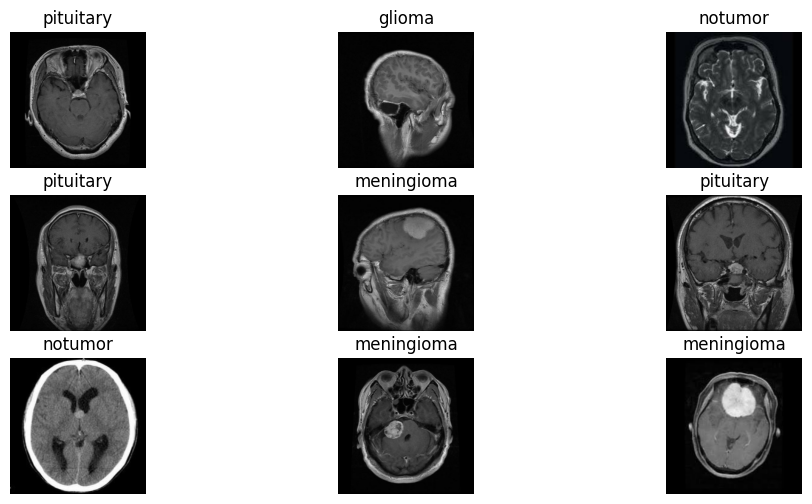

In [ ]:

# Display sample images
plt.figure(figsize=(12,6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_type[labels[i]])
        plt.axis("off")
plt.show()


In [ ]:
def count_class_distribution(dataset, class_names):
    counts = {name: 0 for name in class_names}

    for images, labels in dataset.unbatch():
        label = int(labels.numpy())
        counts[class_names[label]] += 1

    return counts



In [ ]:
train_counts = count_class_distribution(train_ds, train_ds.class_names)
valid_counts = count_class_distribution(valid_ds, valid_ds.class_names)
test_counts  = count_class_distribution(test_ds, test_ds.class_names)

print("\nTraining distribution:", train_counts)
print("Validation distribution:", valid_counts)
print("Test distribution:", test_counts)


Training distribution: {'glioma': 1090, 'meningioma': 1042, 'notumor': 1274, 'pituitary': 1164}
Validation distribution: {'glioma': 231, 'meningioma': 297, 'notumor': 321, 'pituitary': 293}
Test distribution: {'glioma': 300, 'meningioma': 306, 'notumor': 405, 'pituitary': 300}


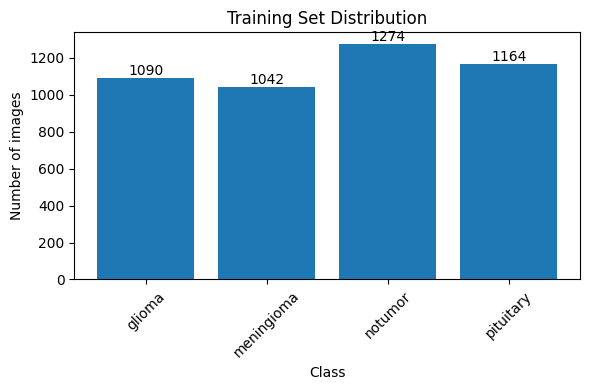

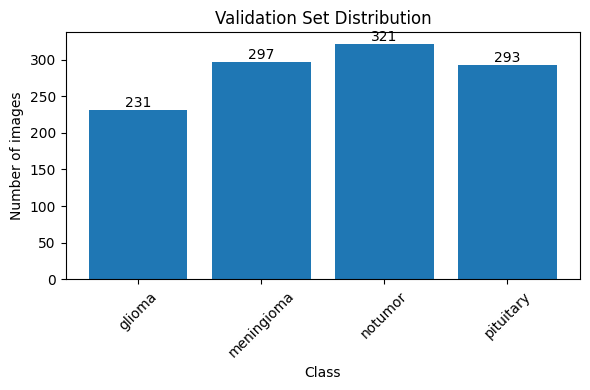

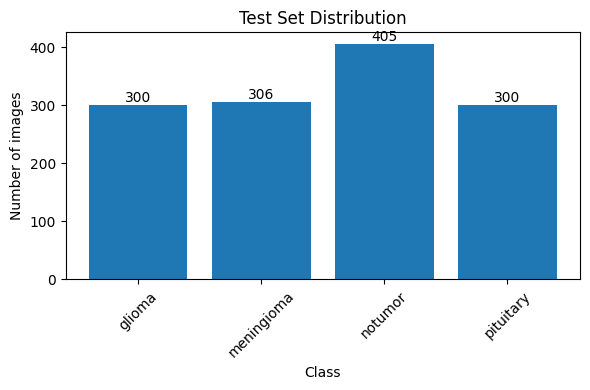

In [ ]:
import matplotlib.pyplot as plt
def plot_distribution(counts, title):
    plt.figure(figsize=(6,4))

    classes = list(counts.keys())
    values = list(counts.values())

    bars = plt.bar(classes, values)

    # Add numbers on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            str(height),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



plot_distribution(train_counts, "Training Set Distribution")
plot_distribution(valid_counts, "Validation Set Distribution")
plot_distribution(test_counts,  "Test Set Distribution")


In [ ]:
# ===================================================
#  Normalize datasets
# ===================================================
normalization_layer = layers.Rescaling(1./255)
train_ds_rescale = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
valid_ds_rescale = valid_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds_rescale  = test_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)

In [ ]:
# Extract labels from the dataset
y_test = np.concatenate([y.numpy() for _, y in test_ds_rescale], axis=0)

# Helper Functions

In [ ]:
def make_callbacks(name):
    ckpt_path = os.path.join(OUT_DIR, f"{name}_best.keras")
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        # ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
        ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, save_weights_only=False)
    ]
    return callbacks

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, metrics=['accuracy', 'loss'], optional_metrics=['precision', 'recall', 'f1_score']):
    """
    Plots training and validation metrics from a Keras history object.

    Parameters:
    - history: Keras History object returned by model.fit()
    - metrics: List of main metrics to plot (default: ['accuracy', 'loss'])
    - optional_metrics: List of optional metrics (like precision, recall, f1_score)
    """
    # Plot main metrics (accuracy, loss)
    plt.figure(figsize=(14,5))
    for i, metric in enumerate(metrics):
        plt.subplot(1, len(metrics), i+1)
        if metric in history.history:
            plt.plot(history.history[metric], label=f'Training {metric}', marker='x', alpha=0.5)
        val_metric = f'val_{metric}'
        if val_metric in history.history:
            plt.plot(history.history[val_metric], label=f'Validation {metric}', marker='o')
        plt.title(f'{metric.capitalize()} over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Plot optional metrics if available
    available_optional = [f'val_{m}' for m in optional_metrics if f'val_{m}' in history.history]
    if available_optional:
        plt.figure(figsize=(7,4))
        for m in available_optional:
            plt.plot(history.history[m], label=m.replace('val_', 'Validation ').capitalize(), marker='o')
        plt.title('Optional Validation Metrics over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)
        plt.show()


In [ ]:
# -------------------------------
#  Test / Prediction Function
# -------------------------------
def test_model(model, X_test):
    """
    Generates predictions on the test set.

    Parameters:
    - model: Trained Keras model
    - X_test: Test features (numpy array or tf dataset)

    Returns:
    - y_pred: Predicted labels
    - y_prob: Predicted probabilities
    """
    y_prob = model.predict(X_test)

    if y_prob.shape[1] > 1:  # multi-class
        y_pred = np.argmax(y_prob, axis=1)
    else:  # binary
        y_pred = (y_prob > 0.5).astype(int).reshape(-1)

    return y_pred, y_prob


In [ ]:
# -------------------------------
#  Evaluation Function
# -------------------------------
def evaluate_model(y_true, y_pred, y_prob=None, class_names=None, plot_roc=True):
    """
    Evaluates predictions: computes metrics, plots confusion matrix and ROC curve.

    Parameters:
    - y_true: True labels
    - y_pred: Predicted labels
    - y_prob: Predicted probabilities (optional, needed for ROC)
    - class_names: List of class names for confusion matrix
    - plot_roc: Whether to plot ROC curve

    Returns:
    - metrics_dict: Dictionary of evaluation metrics
    """
    # -------------------------------
    # Metrics
    # -------------------------------
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')

    metrics_dict = {
        'accuracy': acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }

    print("Evaluation Metrics:")
    for k, v in metrics_dict.items():
        print(f"{k.capitalize()}: {v:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    # -------------------------------
    # Confusion Matrix
    # -------------------------------
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names if class_names else np.unique(y_true),
                yticklabels=class_names if class_names else np.unique(y_true))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    # -------------------------------
    # ROC Curve
    # -------------------------------
    if plot_roc and y_prob is not None:
        plt.figure(figsize=(7,5))
        n_classes = y_prob.shape[1] if len(y_prob.shape) > 1 else 1

        if n_classes == 1:  # binary
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        else:  # multi-class
            y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

        plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

    return metrics_dict

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import pandas as pd

def compare_models_side_by_side(model1, model2, test_ds, class_names=None):
    """
    Compare two models on the same test set:
    - Confusion matrices side by side
    - ROC curves side by side
    - Metrics table (accuracy, F1, precision, recall)

    Parameters:
    - model1, model2: Trained Keras models
    - test_ds: tf.data.Dataset containing (image, label) pairs
    - class_names: list of class names for confusion matrix
    """
    # -------------------------------
    # Extract y_test
    # -------------------------------
    y_test = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test = np.argmax(y_test, axis=1)

    # -------------------------------
    # Helper function for predictions
    # -------------------------------
    def get_preds(model):
        y_prob = model.predict(test_ds)
        if y_prob.shape[1] > 1:
            y_pred = np.argmax(y_prob, axis=1)
        else:
            y_pred = (y_prob > 0.5).astype(int).reshape(-1)
        return y_pred, y_prob

    y_pred1, y_prob1 = get_preds(model1)
    y_pred2, y_prob2 = get_preds(model2)

    # -------------------------------
    # Confusion Matrices Side by Side
    # -------------------------------
    cm1 = confusion_matrix(y_test, y_pred1)
    cm2 = confusion_matrix(y_test, y_pred2)

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title("Model 1 - Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title("Model 2 - Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

    # -------------------------------
    # ROC Curves Side by Side
    # -------------------------------
    n_classes = y_prob1.shape[1] if len(y_prob1.shape) > 1 else 1

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    if n_classes == 1:  # binary
        fpr1, tpr1, _ = roc_curve(y_test, y_prob1)
        fpr2, tpr2, _ = roc_curve(y_test, y_prob2)
        axes[0].plot(fpr1, tpr1, color='darkorange', lw=2)
        axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        axes[0].set_title("Model 1 - ROC Curve")
        axes[0].set_xlabel("FPR")
        axes[0].set_ylabel("TPR")

        axes[1].plot(fpr2, tpr2, color='darkgreen', lw=2)
        axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        axes[1].set_title("Model 2 - ROC Curve")
        axes[1].set_xlabel("FPR")
        axes[1].set_ylabel("TPR")
    else:
        y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
        for i in range(n_classes):
            fpr1, tpr1, _ = roc_curve(y_test_bin[:, i], y_prob1[:, i])
            fpr2, tpr2, _ = roc_curve(y_test_bin[:, i], y_prob2[:, i])
            axes[0].plot(fpr1, tpr1, lw=2, label=f'Class {class_names[i]}')
            axes[1].plot(fpr2, tpr2, lw=2, label=f'Class {class_names[i]}')
        axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[0].set_title("Model 1 - ROC Curve")
        axes[1].set_title("Model 2 - ROC Curve")
        for ax in axes:
            ax.set_xlabel("FPR")
            ax.set_ylabel("TPR")
            ax.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    # -------------------------------
    # Metrics Table
    # -------------------------------
    metrics_model1 = {
        'accuracy': accuracy_score(y_test, y_pred1),
        'f1_score': f1_score(y_test, y_pred1, average='weighted'),
        'precision': precision_score(y_test, y_pred1, average='weighted'),
        'recall': recall_score(y_test, y_pred1, average='weighted')
    }
    metrics_model2 = {
        'accuracy': accuracy_score(y_test, y_pred2),
        'f1_score': f1_score(y_test, y_pred2, average='weighted'),
        'precision': precision_score(y_test, y_pred2, average='weighted'),
        'recall': recall_score(y_test, y_pred2, average='weighted')
    }

    metrics_df = pd.DataFrame([metrics_model1, metrics_model2], index=['Model 1', 'Model 2'])
    print("=== F1, Precision, Recall, Accuracy Comparison ===")
    # display(metrics_df)

    return metrics_df


# Building Models

## Build the base model,training and testing


In [ ]:
# tiny baseline: one conv block and a small dense head
base_model_type = models.Sequential([
    layers.Input(shape=(INPUT_SHAPE)),
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES_TYPE, activation='softmax')
])
base_model_type.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
base_model_type.summary()
history_task1_baseline = base_model_type.fit(
    train_ds_rescale, validation_data=valid_ds_rescale,
    epochs=15, callbacks=make_callbacks("task1_baseline")
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 197136)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    12,616,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,852,430 (144.40 MB)

 Trainable params: 12,617,476 (48.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,234,954 (96.26 MB)

Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 37s 259ms/step - accuracy: 0.6699 - loss: 0.8181 - val_accuracy: 0.8669 - val_loss: 0.4621 - learning_rate: 0.0010
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7966 - loss: 0.5344 - val_accuracy: 0.8940 - val_loss: 0.3465 - learning_rate: 0.0010
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8557 - loss: 0.3806 - val_accuracy: 0.8975 - val_loss: 0.2994 - learning_rate: 0.0010
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9072 - loss: 0.2652 - val_accuracy: 0.8914 - val_loss: 0.3355 - learning_rate: 0.0010
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9202 - loss: 0.2221 - val_accuracy: 0.8914 - val_loss: 0.3929 - learning_rate: 0.0010
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9144 - loss: 0.2084 - val_accuracy: 0.9133 - val_loss: 0.3040 - learning_rate: 0.0010
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9478 - loss: 

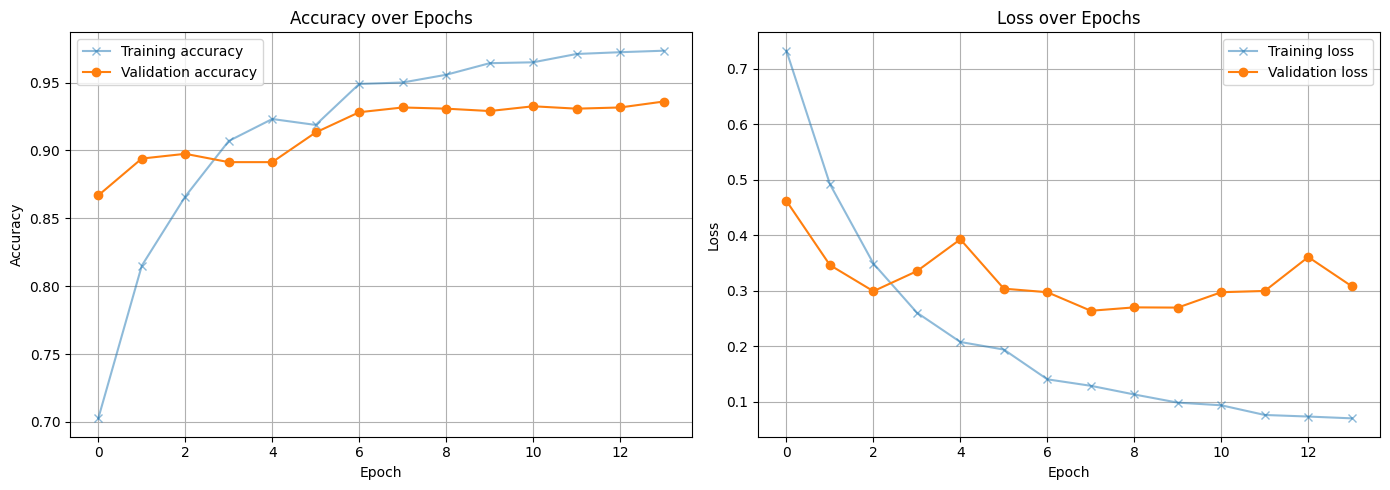

In [ ]:
plot_training_history(history_task1_baseline)


In [ ]:
y_pred, y_prob = test_model(base_model_type, test_ds_rescale)

41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step


Evaluation Metrics:
Accuracy: 0.9214
F1_score: 0.9204
Precision: 0.9201
Recall: 0.9214

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.86      0.89       300
           1       0.85      0.82      0.84       306
           2       0.95      1.00      0.97       405
           3       0.96      0.98      0.97       300

    accuracy                           0.92      1311
   macro avg       0.92      0.92      0.92      1311
weighted avg       0.92      0.92      0.92      1311



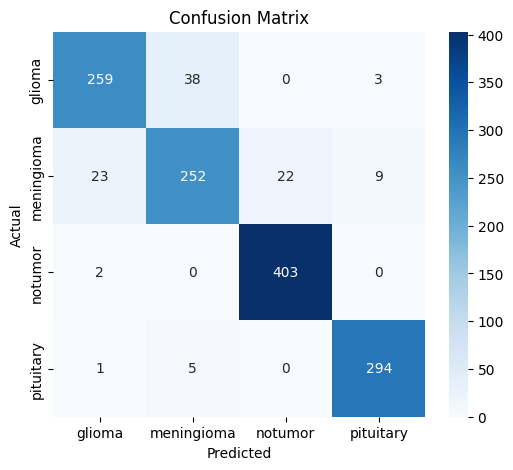

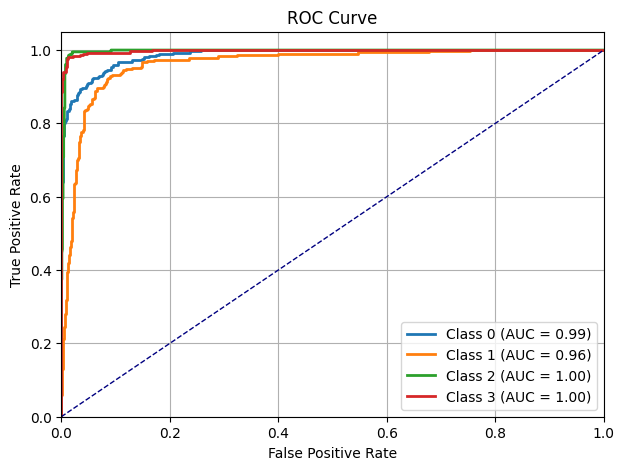

In [ ]:
#  Evaluate predictions
metrics = evaluate_model(y_test, y_pred, y_prob=y_prob, class_names=class_names_type)

## Build custom 3-layer CNN-training and testing

In [ ]:
 # The 3-layer CNN approach
custom_model_type = models.Sequential([

    layers.Input(shape=IMG_SIZE + (3,)),  # 3 channels for RGB

    # Convolution + MaxPooling blocks
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Fully connected classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # helps reduce overfitting
    layers.Dense(NUM_CLASSES_TYPE, activation='softmax') # output layer
])

# Compile the model with optimizer, loss, and evaluation metric
custom_model_type.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
custom_model_type.summary()

In [ ]:

history_task1_customCNN = custom_model_type.fit(
    train_ds_rescale, validation_data=valid_ds_rescale,
    epochs=15, callbacks=make_callbacks("task1_customCNN")
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 28s 125ms/step - accuracy: 0.5924 - loss: 0.9883 - val_accuracy: 0.8363 - val_loss: 0.4575
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.8199 - loss: 0.4531 - val_accuracy: 0.8608 - val_loss: 0.3723
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 22s 156ms/step - accuracy: 0.8709 - loss: 0.3375 - val_accuracy: 0.9054 - val_loss: 0.3139
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 29s 201ms/step - accuracy: 0.9167 - loss: 0.2309 - val_accuracy: 0.9168 - val_loss: 0.2612
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 23s 163ms/step - accuracy: 0.9319 - loss: 0.1629 - val_accuracy: 0.9264 - val_loss: 0.2298
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 216ms/step - accuracy: 0.9573 - loss: 0.1246 - val_accuracy: 0.9308 - val_loss: 0.2224
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9573 - loss: 0.1010 - val_accuracy: 0.9396 - val_loss: 0.2265
Epoch 8/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.9750 - loss: 0.070

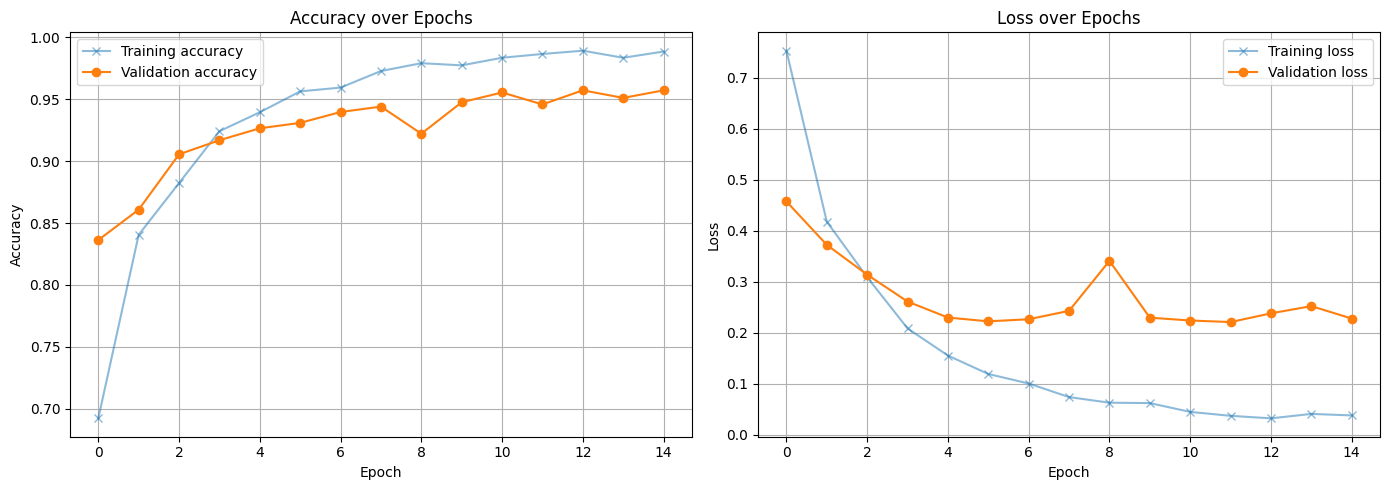

In [ ]:
plot_training_history(history_task1_customCNN)

In [ ]:
y_pred, y_prob = test_model(custom_model_type, test_ds_rescale)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


Evaluation Metrics:
Accuracy: 0.9489
F1_score: 0.9486
Precision: 0.9487
Recall: 0.9489

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       300
           1       0.90      0.89      0.89       306
           2       0.96      0.99      0.97       405
           3       0.97      0.98      0.98       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311



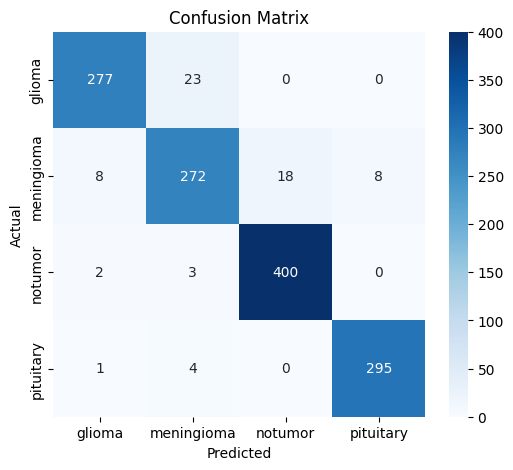

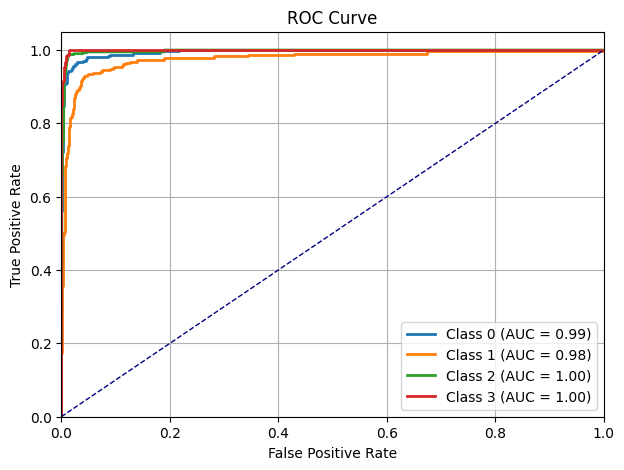

In [ ]:
#  Evaluate predictions
metrics = evaluate_model(y_test, y_pred, y_prob=y_prob, class_names=class_names_type)

## Compare base_model vs custom_CNNmodel

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


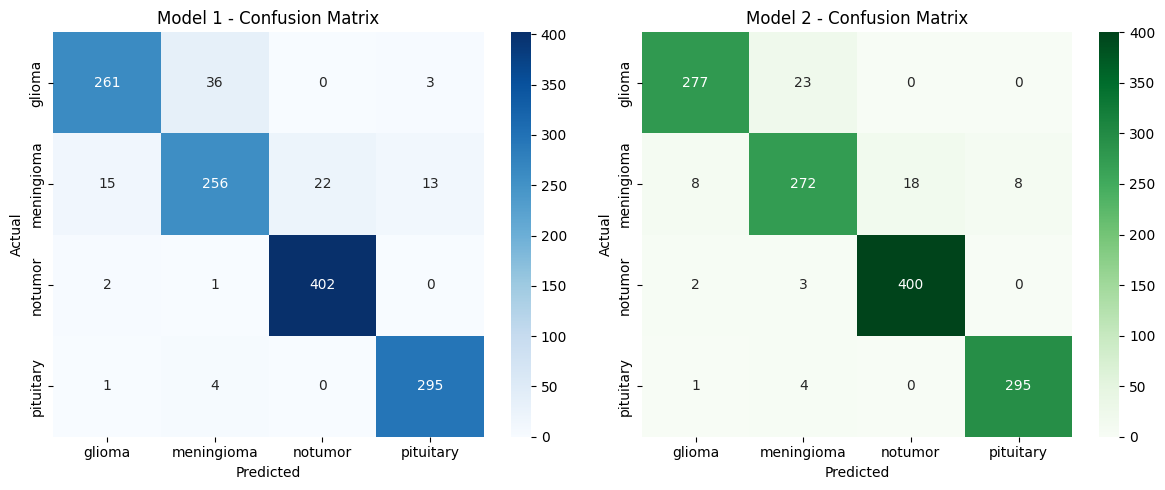

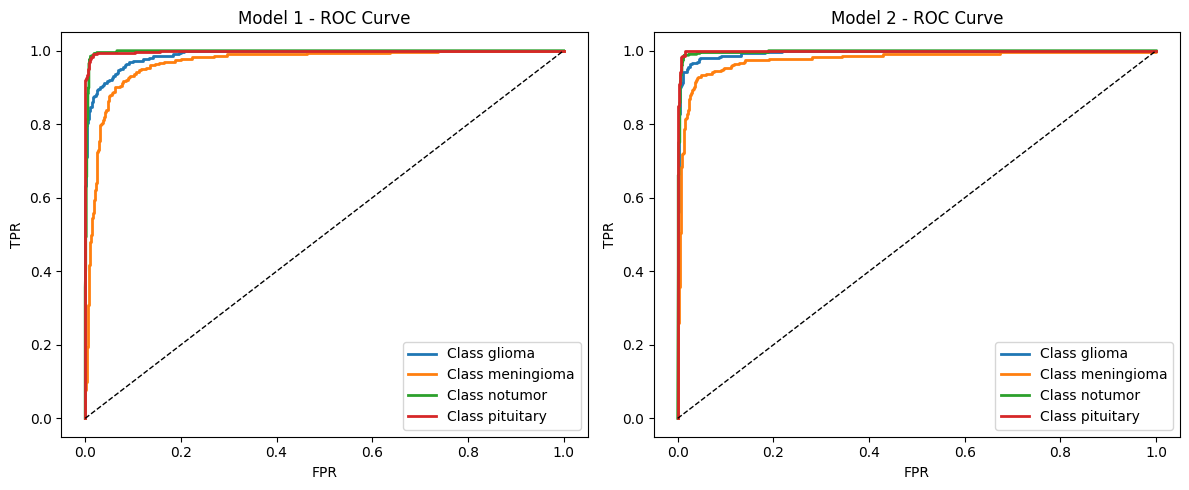

=== F1, Precision, Recall, Accuracy Comparison ===


,accuracy,f1_score,precision,recall
Model 1,0.926011,0.925067,0.925213,0.926011
Model 2,0.948894,0.948632,0.948729,0.948894


In [ ]:
# Compare base_model vs custom_CNNmodel

compare_models_side_by_side(base_model_type, custom_model_type, test_ds_rescale, class_names=class_names_type)

# Implementing Domain Shift Adaption

## Domain Shift on Base Model

In [ ]:
# ===================================================
#  Define Data Augmentation
# ===================================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


In [ ]:
# tiny baseline with augmentation: one conv block and a small dense head
base_model_type_aug = models.Sequential([
    layers.Input(shape=(INPUT_SHAPE)),
    data_augmentation,
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES_TYPE, activation='softmax')
])
base_model_type_aug.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Display model architecture
base_model_type_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 197136)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    12,616,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,617,476 (48.13 MB)

 Trainable params: 12,617,476 (48.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history_task1_aug = base_model_type_aug.fit(
    train_ds_rescale, validation_data=valid_ds_rescale,
    epochs=15, callbacks=make_callbacks("task1_baseline_aug")
)

Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 46s 272ms/step - accuracy: 0.3649 - loss: 1.9840 - val_accuracy: 0.5228 - val_loss: 1.0464
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.4946 - loss: 1.0518 - val_accuracy: 0.6935 - val_loss: 0.7898
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.5906 - loss: 0.9162 - val_accuracy: 0.7189 - val_loss: 0.7200
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.6455 - loss: 0.8308 - val_accuracy: 0.7837 - val_loss: 0.6411
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.6924 - loss: 0.7282 - val_accuracy: 0.7890 - val_loss: 0.5832
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.7108 - loss: 0.6986 - val_accuracy: 0.7715 - val_loss: 0.5391
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.7100 - loss: 0.6797 - val_accuracy: 0.7925 - val_loss: 0.5258
Epoch 8/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.7133 - loss: 0.686

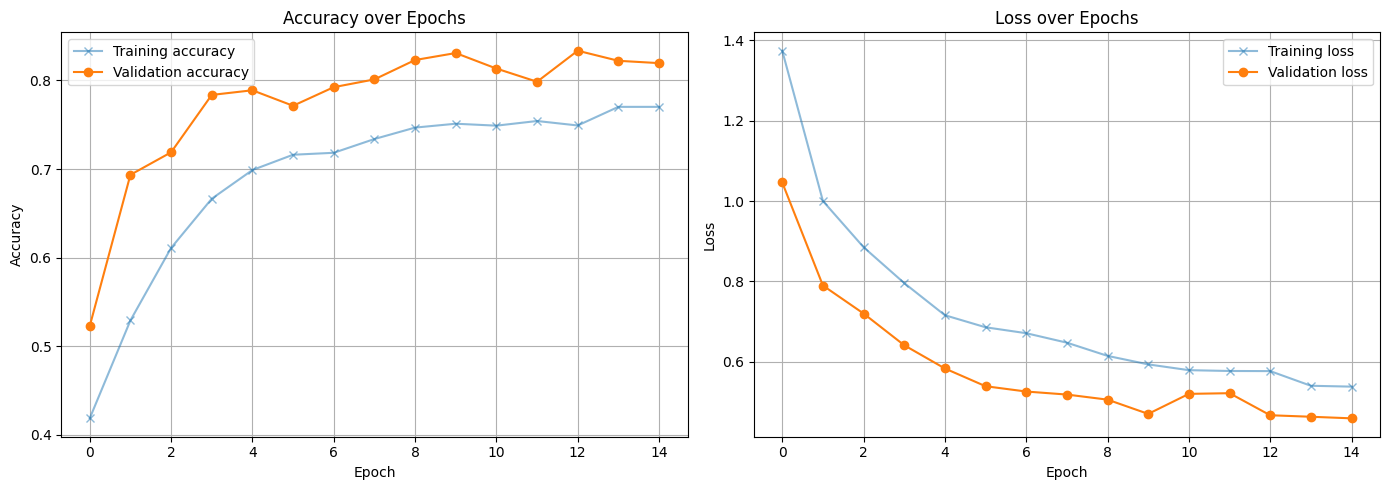

In [ ]:
plot_training_history(history_task1_aug)

In [ ]:
y_pred, y_prob = test_model(base_model_type_aug, test_ds_rescale)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


Evaluation Metrics:
Accuracy: 0.7780
F1_score: 0.7616
Precision: 0.7603
Recall: 0.7780

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.70      0.74       300
           1       0.59      0.41      0.48       306
           2       0.81      0.98      0.88       405
           3       0.85      0.96      0.90       300

    accuracy                           0.78      1311
   macro avg       0.76      0.76      0.75      1311
weighted avg       0.76      0.78      0.76      1311



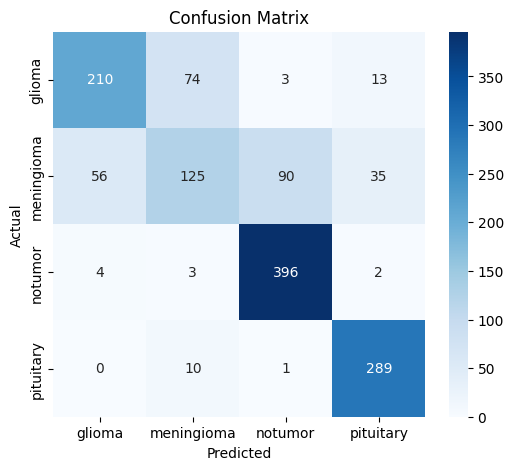

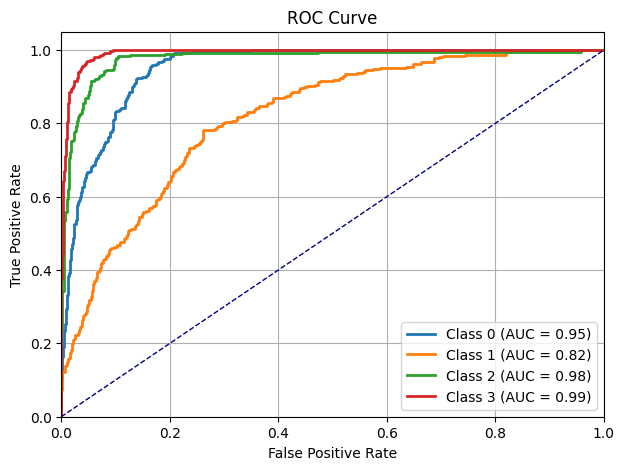

In [ ]:
#  Evaluate predictions
metrics = evaluate_model(y_test, y_pred, y_prob=y_prob, class_names=class_names_type)

## Domain Shift on the Custom 3-layer CNN

In [ ]:
# ===================================================
# CNN Model with Data Augmentation (Tumor Type)
# ===================================================
custom_model_type_aug = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),  # Input layer first
    data_augmentation,                    # Data augmentation
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES_TYPE, activation='softmax')
])

custom_model_type_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
custom_model_type_aug.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_task1_customCNN_aug = custom_model_type_aug.fit(
    train_ds_rescale, validation_data=valid_ds_rescale,
    epochs=15, callbacks=make_callbacks("task1_customCNN_aug")
)

Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 27s 166ms/step - accuracy: 0.5008 - loss: 1.1060 - val_accuracy: 0.7776 - val_loss: 0.5954
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 126ms/step - accuracy: 0.7454 - loss: 0.6971 - val_accuracy: 0.8179 - val_loss: 0.5157
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.7740 - loss: 0.5654 - val_accuracy: 0.8004 - val_loss: 0.5597
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 23s 161ms/step - accuracy: 0.7968 - loss: 0.5133 - val_accuracy: 0.8363 - val_loss: 0.4396
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 26s 181ms/step - accuracy: 0.8078 - loss: 0.4729 - val_accuracy: 0.8687 - val_loss: 0.3758
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.8390 - loss: 0.4214 - val_accuracy: 0.8634 - val_loss: 0.3735
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.8518 - loss: 0.4076 - val_accuracy: 0.8940 - val_loss: 0.3354
Epoch 8/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8609 - loss: 0.3

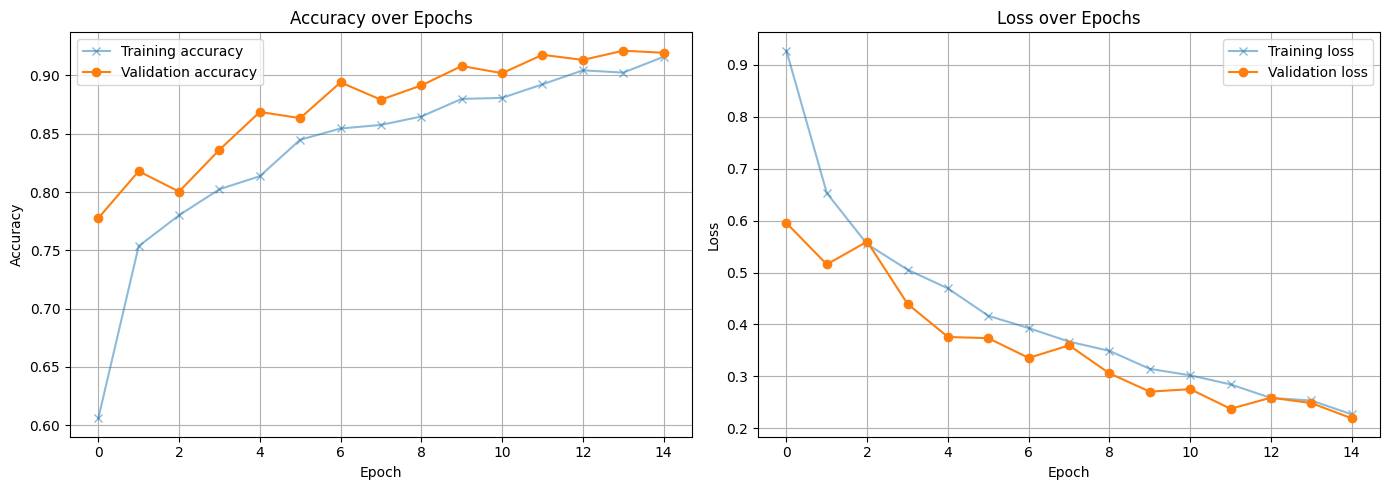

In [ ]:
plot_training_history(history_task1_customCNN_aug)

In [ ]:
y_pred, y_prob = test_model(custom_model_type_aug, test_ds_rescale)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


Evaluation Metrics:
Accuracy: 0.8810
F1_score: 0.8792
Precision: 0.8846
Recall: 0.8810

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.79      0.87       300
           1       0.77      0.74      0.76       306
           2       0.86      0.99      0.92       405
           3       0.95      0.96      0.96       300

    accuracy                           0.88      1311
   macro avg       0.89      0.87      0.88      1311
weighted avg       0.88      0.88      0.88      1311



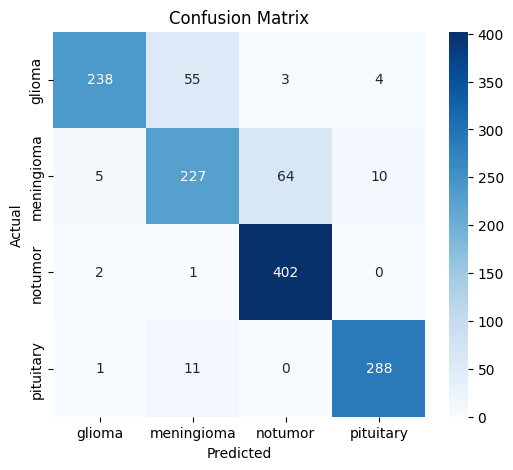

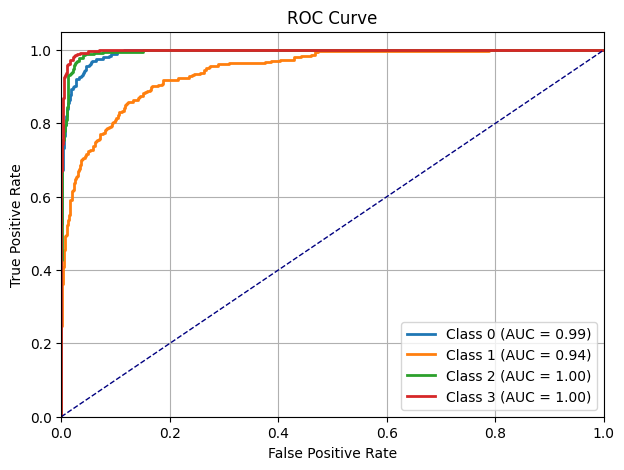

In [ ]:
#  Evaluate predictions
metrics = evaluate_model(y_test, y_pred, y_prob=y_prob, class_names=class_names_type)

## Compare base_model_aug vs custom_CNNmodel_aug

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


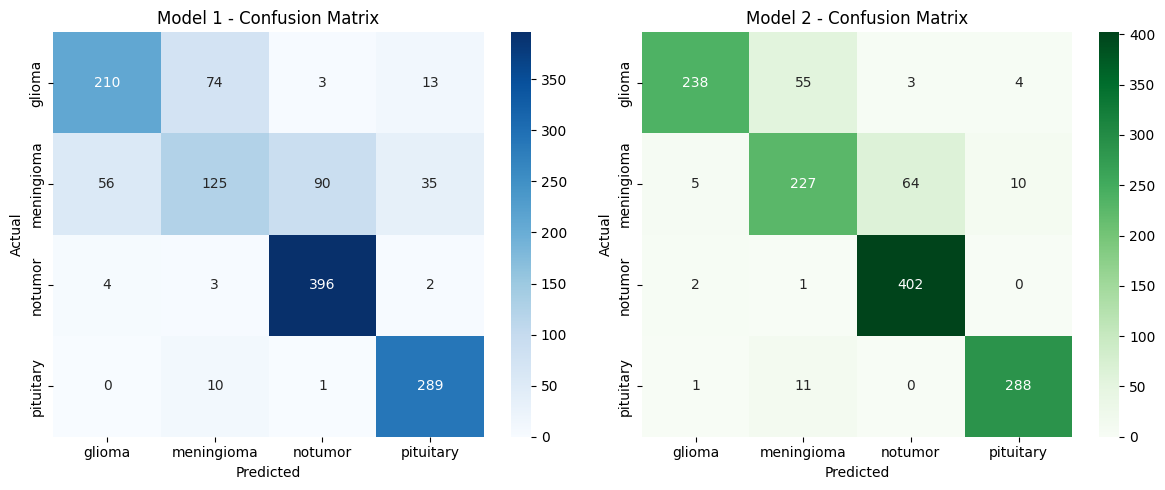

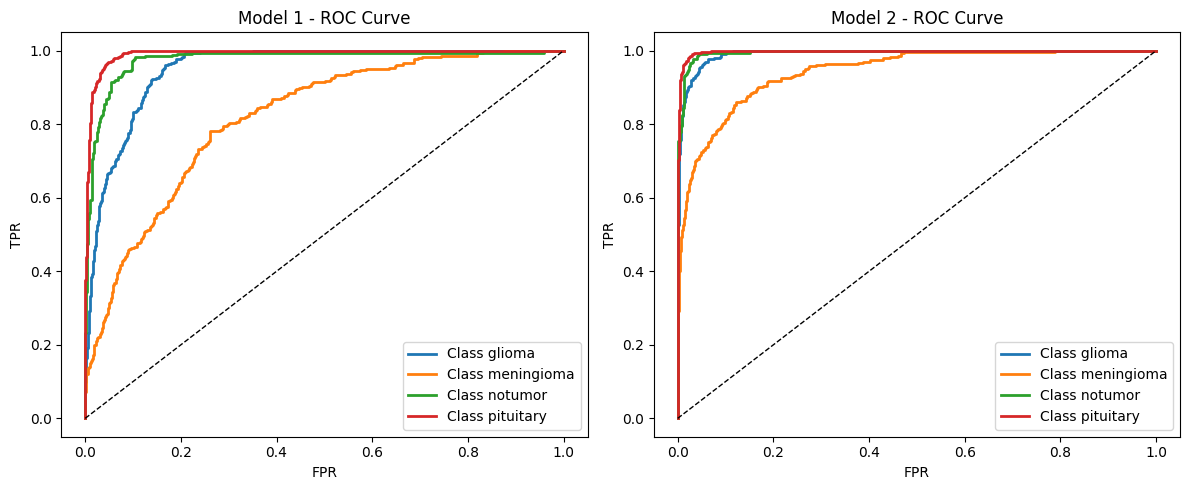

=== F1, Precision, Recall, Accuracy Comparison ===


,accuracy,f1_score,precision,recall
Model 1,0.778032,0.761624,0.760348,0.778032
Model 2,0.881007,0.879241,0.884626,0.881007


In [ ]:
# Compare base_model vs custom_CNNmodel

compare_models_side_by_side(base_model_type_aug, custom_model_type_aug, test_ds_rescale, class_names=class_names_type)

# Full VGG16 pipeline for Grade Classification

## Setting and Import Data

In [ ]:
# ----------------------------
# Combine BraTS2019 + BraTS2020 into patient-level dataset
# Stratified 70/15/15 split for grade classification
# ----------------------------

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ----------------------------
# Paths
# ----------------------------
brats2019_base = "/content/drive/MyDrive/ProjectData/BraTS2019"
brats2020_base = "/content/drive/MyDrive/ProjectData/BraTS2020/BraTS2020_TrainingData"
brats2020_csv = os.path.join(brats2020_base, "name_mapping.csv")

# ----------------------------
# Step 1: Load BraTS2019 patient-level data
# ----------------------------
def get_2019_patient_paths(base_dir):
    patient_files = []
    labels = []

    for label_name, label_val in zip(["HGG","LGG"], [1,0]):  # HGG=1, LGG=0
        folder = os.path.join(base_dir, label_name)
        files = [f for f in os.listdir(folder) if f.endswith(".jpg")]

        # Extract patient IDs from filenames (assume first 3 parts)
        patient_dict = {}
        for f in files:
            patient_id = "_".join(f.split("_")[:3])
            # Only keep first slice per patient
            if patient_id not in patient_dict:
                patient_dict[patient_id] = os.path.join(folder,f)
        for pid, path in patient_dict.items():
            patient_files.append(path)
            labels.append(label_val)

    return np.array(patient_files), np.array(labels)

paths_2019, labels_2019 = get_2019_patient_paths(brats2019_base)
print("2019 dataset:")
print("Total patients:", len(paths_2019))
print("HGG count:", (labels_2019==1).sum(), "LGG count:", (labels_2019==0).sum())

# ----------------------------
# Step 2: Load BraTS2020 patient-level data
# ----------------------------
df20 = pd.read_csv(brats2020_csv)[["BraTS_2020_subject_ID","Grade"]].rename(columns={"BraTS_2020_subject_ID":"case"})

# Explicit mapping to ensure LGG=0, HGG=1
df20['label'] = df20['Grade'].map({'LGG':0, 'HGG':1})

# Collect image paths
all_files_2020 = [f for f in os.listdir(brats2020_base) if f.endswith("_flair.jpg")]
paths_2020 = []
labels_2020 = []
for f in all_files_2020:
    case_id = "_".join(f.split("_")[:3])
    row = df20[df20['case']==case_id]
    if not row.empty:
        paths_2020.append(os.path.join(brats2020_base,f))
        labels_2020.append(row['label'].values[0])
paths_2020 = np.array(paths_2020)
labels_2020 = np.array(labels_2020)
print("2020 dataset:")
print("Total patients:", len(paths_2020))
print("HGG count:", (labels_2020==1).sum(), "LGG count:", (labels_2020==0).sum())

# ----------------------------
# Step 3: Combine 2019 + 2020
# ----------------------------
all_paths = np.concatenate([paths_2019, paths_2020])
all_labels = np.concatenate([labels_2019, labels_2020])
print("Combined dataset:")
print("Total patients:", len(all_paths))
print("HGG count:", (all_labels==1).sum(), "LGG count:", (all_labels==0).sum())

# ----------------------------
# Step 4: Stratified 70/15/15 split
# ----------------------------
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

# Print final counts
def print_counts(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    d = dict(zip(unique, counts))
    print(f"{name} split: {len(labels)} samples - {d}")

print_counts("Train", train_labels)
print_counts("Validation", val_labels)
print_counts("Test", test_labels)

# ----------------------------
# Step 5: Save CSVs for reproducibility
# ----------------------------
out_dir = "/content/drive/MyDrive/ProjectData/combined_splits"
os.makedirs(out_dir, exist_ok=True)
pd.DataFrame({'path':train_paths, 'label':train_labels}).to_csv(os.path.join(out_dir,'train_split.csv'), index=False)
pd.DataFrame({'path':val_paths, 'label':val_labels}).to_csv(os.path.join(out_dir,'val_split.csv'), index=False)
pd.DataFrame({'path':test_paths, 'label':test_labels}).to_csv(os.path.join(out_dir,'test_split.csv'), index=False)

print("Split CSVs saved to:", out_dir)


2019 dataset:
Total patients: 335
HGG count: 259 LGG count: 76
2020 dataset:
Total patients: 369
HGG count: 293 LGG count: 76
Combined dataset:
Total patients: 704
HGG count: 552 LGG count: 152
Train split: 492 samples - {np.int64(0): np.int64(106), np.int64(1): np.int64(386)}
Validation split: 106 samples - {np.int64(0): np.int64(23), np.int64(1): np.int64(83)}
Test split: 106 samples - {np.int64(0): np.int64(23), np.int64(1): np.int64(83)}
Split CSVs saved to: /content/drive/MyDrive/ProjectData/combined_splits


In [ ]:
IMG_SIZE = (224,224)  # VGG16 input
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
OUT_DIR = "/content/drive/MyDrive/ProjectData/combined_splits"
NUM_CLASSES = 2
SEED = 42

In [ ]:
# Load CSV splits
import pandas as pd


# Load CSVs
train_df = pd.read_csv(f"{OUT_DIR}/train_split.csv")
val_df   = pd.read_csv(f"{OUT_DIR}/val_split.csv")
test_df  = pd.read_csv(f"{OUT_DIR}/test_split.csv")

# Access paths and labels
train_paths = train_df['path'].values
train_labels = train_df['label'].values

val_paths = val_df['path'].values
val_labels = val_df['label'].values

test_paths = test_df['path'].values
test_labels = test_df['label'].values

# Optional: print counts to verify
print("Train:", len(train_paths), "Validation:", len(val_paths), "Test:", len(test_paths))
print("Train counts:", dict(pd.Series(train_labels).value_counts()))
print("Validation counts:", dict(pd.Series(val_labels).value_counts()))
print("Test counts:", dict(pd.Series(test_labels).value_counts()))


Train: 492 Validation: 106 Test: 106
Train counts: {1: np.int64(386), 0: np.int64(106)}
Validation counts: {1: np.int64(83), 0: np.int64(23)}
Test counts: {1: np.int64(83), 0: np.int64(23)}


## Data Preprocessing

In [ ]:
def paths_to_dataset(df, shuffle=True):
    paths = df['path'].values
    labels = df['label'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = img / 255.0  # normalize
        return img, label

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(500)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds



In [ ]:
# CHECK LABEL DISTRIBUTION
def print_label_distribution(df, name):
    counts = df['label'].value_counts().sort_index()
    total = len(df)
    print(f"{name} split distribution:")
    for label, count in counts.items():
        pct = count/total*100
        cls_name = "LGG" if label==0 else "HGG"
        print(f"  {cls_name}: {count} samples ({pct:.1f}%)")
    print("-"*40)

print_label_distribution(train_df, "Train")
print_label_distribution(val_df, "Validation")
print_label_distribution(test_df, "Test")

Train split distribution:
  LGG: 106 samples (21.5%)
  HGG: 386 samples (78.5%)
----------------------------------------
Validation split distribution:
  LGG: 23 samples (21.7%)
  HGG: 83 samples (78.3%)
----------------------------------------
Test split distribution:
  LGG: 23 samples (21.7%)
  HGG: 83 samples (78.3%)
----------------------------------------


/tmp/ipython-input-1723110285.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts.values, palette='pastel')


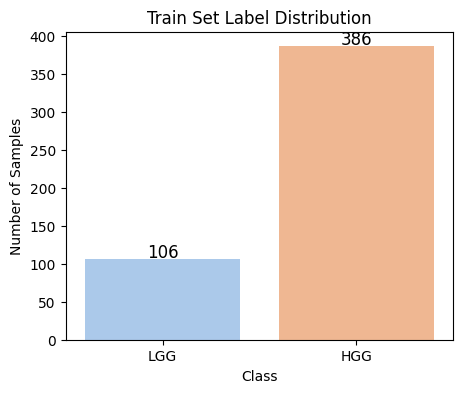

/tmp/ipython-input-1723110285.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts.values, palette='pastel')


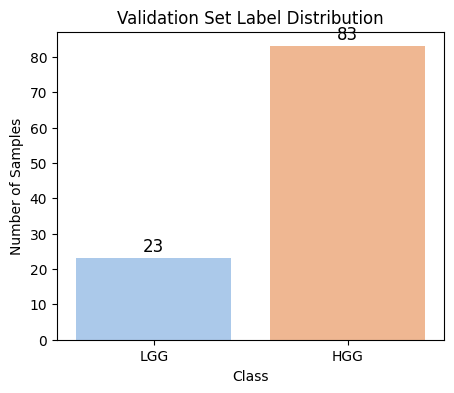

/tmp/ipython-input-1723110285.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts.values, palette='pastel')


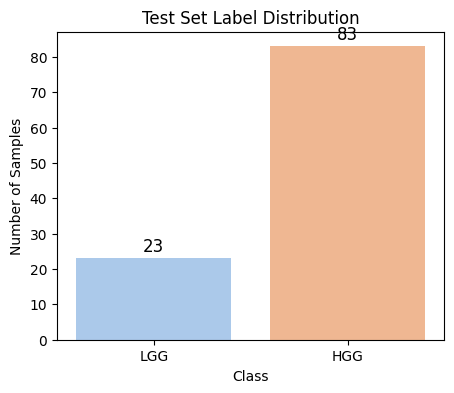

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_label_distribution(df, split_name):
    counts = df['label'].value_counts().sort_index()
    class_names = ['LGG', 'HGG']

    plt.figure(figsize=(5,4))
    sns.barplot(x=class_names, y=counts.values, palette='pastel')
    plt.title(f'{split_name} Set Label Distribution')
    plt.ylabel('Number of Samples')
    plt.xlabel('Class')
    for i, count in enumerate(counts.values):
        plt.text(i, count + 2, str(count), ha='center', fontsize=12)
    plt.show()

# Plot for each split
plot_label_distribution(train_df, "Train")
plot_label_distribution(val_df, "Validation")
plot_label_distribution(test_df, "Test")


In [ ]:
# Oversampling minority class
import numpy as np

# Separate indices by class
idx_lgg = np.where(train_df['label']==0)[0]
idx_hgg = np.where(train_df['label']==1)[0]

# Oversample LGG to match HGG
oversample_factor = len(idx_hgg) // len(idx_lgg)
idx_lgg_oversampled = np.repeat(idx_lgg, oversample_factor)
extra = len(idx_hgg) - len(idx_lgg_oversampled)
if extra > 0:
    idx_lgg_oversampled = np.concatenate([idx_lgg_oversampled,
                                         np.random.choice(idx_lgg, size=extra, replace=True)])

# Combine and shuffle
new_indices = np.concatenate([idx_hgg, idx_lgg_oversampled])
np.random.shuffle(new_indices)

train_df_balanced = train_df.iloc[new_indices].reset_index(drop=True)

# Updated distribution
print("Balanced train distribution:")
print(train_df_balanced['label'].value_counts())


Balanced train distribution:
label
0    386
1    386
Name: count, dtype: int64


In [ ]:
# Create the TRAIN / VAL / TEST datasets
train_ds = paths_to_dataset(train_df_balanced, shuffle=True)
val_ds   = paths_to_dataset(val_df, shuffle=False)
test_ds  = paths_to_dataset(test_df, shuffle=False)


## Building Grade Classification Models

###  BaseModel VGG16

### vgg- 128

In [ ]:
# Build Baseline VGG16 (frozen)
base_model = VGG16(include_top=False, input_shape=IMG_SIZE+(3,), weights='imagenet')
base_model.trainable = False  # frozen

model_baseline = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # binary classification
])


model_baseline.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model_baseline.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Callbacks
callbacks_baseline = make_callbacks("vgg16_baseline")

In [ ]:

# Train baseline
history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_baseline
)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 565s 11s/step - accuracy: 0.5071 - loss: 0.8259 - val_accuracy: 0.4811 - val_loss: 0.6932
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 597s 11s/step - accuracy: 0.5352 - loss: 0.6952 - val_accuracy: 0.5472 - val_loss: 0.6857
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 468s 10s/step - accuracy: 0.5151 - loss: 0.7053 - val_accuracy: 0.5849 - val_loss: 0.6798
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 528s 10s/step - accuracy: 0.5720 - loss: 0.6899 - val_accuracy: 0.5849 - val_loss: 0.6755
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 494s 10s/step - accuracy: 0.5259 - loss: 0.6966 - val_accuracy: 0.6038 - val_loss: 0.6686
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 495s 10s/step - accuracy: 0.5684 - loss: 0.6827 - val_accuracy: 0.5943 - val_loss: 0.6702
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 502s 10s/step - accuracy: 0.5558 - loss: 0.6727 - val_accuracy: 0.6698 - val_loss: 0.6544
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 491s 10s/step - accuracy: 0.5719 - loss: 0.6846 - val_accuracy: 0.

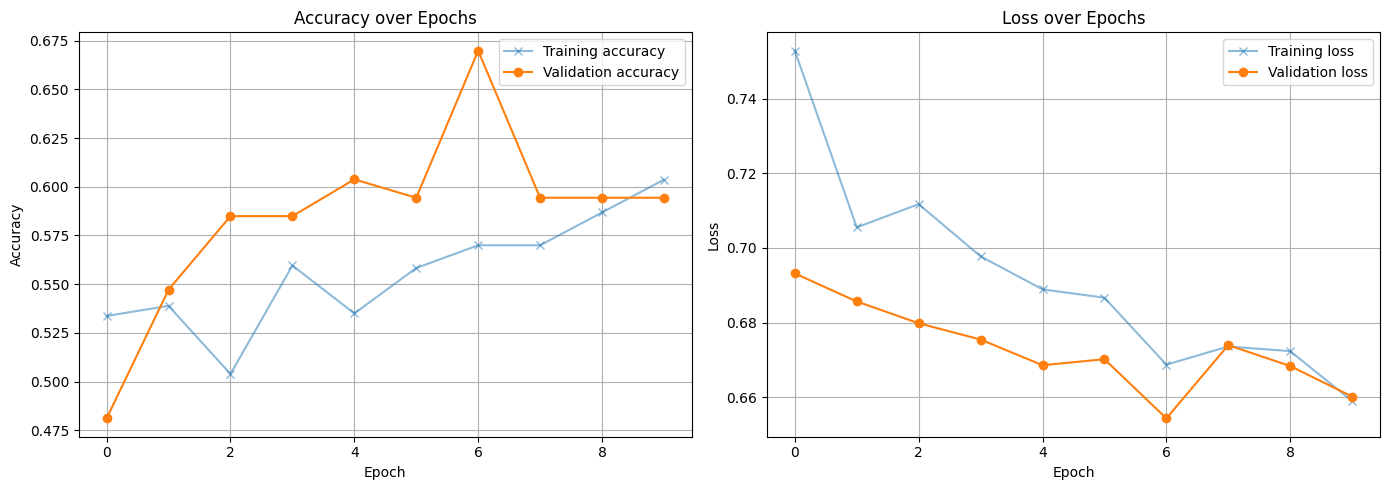

In [ ]:
# Plot training history
plot_training_history(history_baseline)

7/7 ━━━━━━━━━━━━━━━━━━━━ 64s 8s/step
Evaluation Metrics:
Accuracy: 0.6792
F1_score: 0.7019
Precision: 0.7458
Recall: 0.6792

Classification Report:

              precision    recall  f1-score   support

           0       0.35      0.57      0.43        23
           1       0.86      0.71      0.78        83

    accuracy                           0.68       106
   macro avg       0.60      0.64      0.60       106
weighted avg       0.75      0.68      0.70       106



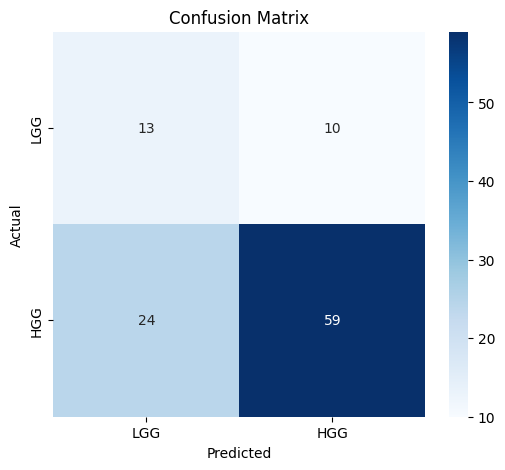

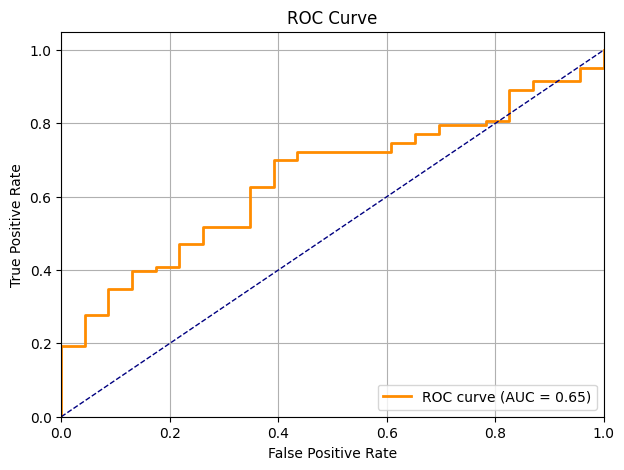

{'accuracy': 0.6792452830188679,
 'f1_score': 0.701895067858325,
 'precision': 0.7457744865456104,
 'recall': 0.6792452830188679}

In [ ]:
# Evaluate on test set
y_pred_baseline, y_prob_baseline = test_model(model_baseline, test_ds)
evaluate_model(
y_true=np.concatenate([y for _,y in test_ds], axis=0),
y_pred=y_pred_baseline,
y_prob=y_prob_baseline,
class_names=["LGG","HGG"]
)


### vgg 256

In [ ]:
# Build Baseline VGG16 (frozen)
base_model = VGG16(include_top=False, input_shape=IMG_SIZE+(3,), weights='imagenet')
base_model.trainable = False  # frozen

model_baseline = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # binary classification
])


model_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model_baseline.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Callbacks
callbacks_baseline = make_callbacks("vgg16_baseline_256")

In [ ]:
checkpoint_baseline = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/ProjectData/BraTS2020/best_vgg16_model_baseline.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

history_baseline_VGG16 = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_baseline]
)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.5185 - loss: 0.7219 - val_accuracy: 0.3585 - val_loss: 0.6987
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - accuracy: 0.4887 - loss: 0.7391 - val_accuracy: 0.7736 - val_loss: 0.6692
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - accuracy: 0.5247 - loss: 0.7220 - val_accuracy: 0.6321 - val_loss: 0.6823
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - accuracy: 0.5498 - loss: 0.7061 - val_accuracy: 0.7358 - val_loss: 0.6687
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - accuracy: 0.5433 - loss: 0.7061 - val_accuracy: 0.6321 - val_loss: 0.6741
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - accuracy: 0.4534 - loss: 0.7305 - val_accuracy: 0.4340 - val_loss: 0.7009
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - accuracy: 0.5167 - loss: 0.7192 - val_accuracy: 0.6698 - val_loss: 0.6642
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step - accuracy: 0.5527 - loss: 0.6950 - val_accuracy: 0.5

### FINE-TUNE VGG16

In [ ]:
# Load same model (reuse)
model_finetune = model_baseline

# Unfreeze last 10 layers of VGG16
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model_finetune.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = model_finetune.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-7
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True
        )
    ]
)


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 628ms/step - accuracy: 0.5698 - loss: 0.6745 - val_accuracy: 0.7642 - val_loss: 0.5657 - learning_rate: 1.0000e-05
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 299ms/step - accuracy: 0.6595 - loss: 0.5922 - val_accuracy: 0.7736 - val_loss: 0.4816 - learning_rate: 1.0000e-05
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 304ms/step - accuracy: 0.7159 - loss: 0.5296 - val_accuracy: 0.7736 - val_loss: 0.4531 - learning_rate: 1.0000e-05
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 303ms/step - accuracy: 0.7538 - loss: 0.4846 - val_accuracy: 0.6981 - val_loss: 0.5537 - learning_rate: 1.0000e-05
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 307ms/step - accuracy: 0.7794 - loss: 0.4468 - val_accuracy: 0.7642 - val_loss: 0.4551 - learning_rate: 1.0000e-05
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 318ms/step - accuracy: 0.8123 - loss: 0.4001 - val_accuracy: 0.7642 - val_loss: 0.4446 - learning_rate: 5.0000e-06
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 303ms/step - accur

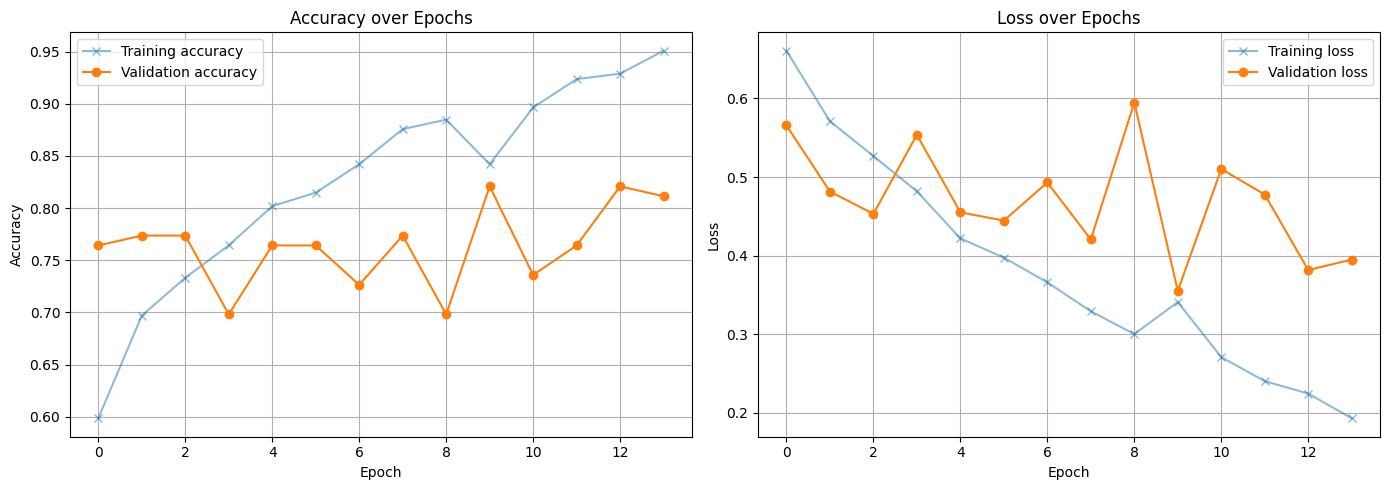

In [ ]:
plot_training_history(history_finetune)

4/4 ━━━━━━━━━━━━━━━━━━━━ 88s 15s/step
Evaluation Metrics:
Accuracy: 0.7925
F1_score: 0.7628
Precision: 0.7613
Recall: 0.7925

Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.26      0.35        23
           1       0.82      0.94      0.88        83

    accuracy                           0.79       106
   macro avg       0.68      0.60      0.61       106
weighted avg       0.76      0.79      0.76       106



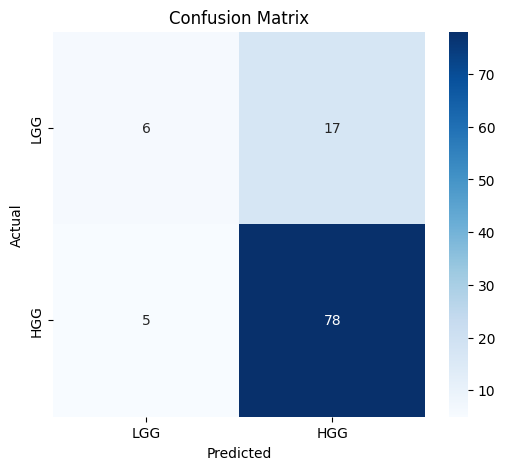

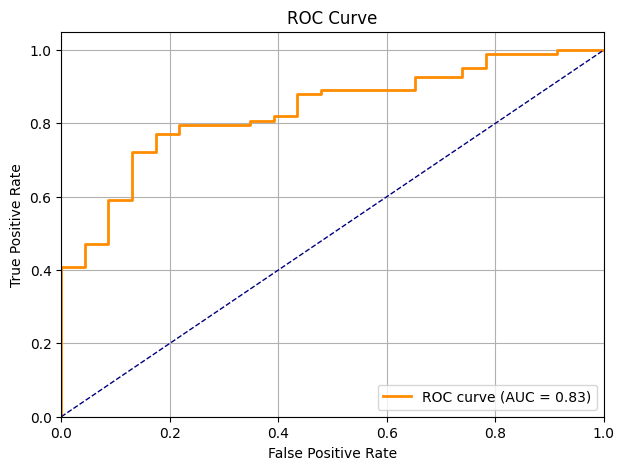

{'accuracy': 0.7924528301886793,
 'f1_score': 0.762822831061617,
 'precision': 0.7612530468538413,
 'recall': 0.7924528301886793}

In [ ]:
y_pred_finetune, y_prob_finetune = test_model(model_finetune, test_ds)
evaluate_model(
    y_true=np.concatenate([y for _,y in test_ds], axis=0),
    y_pred=y_pred_finetune,
    y_prob=y_prob_finetune,
    class_names=["LGG","HGG"]
)

In [ ]:
baseline = tf.keras.models.load_model(
    "/content/drive/MyDrive/ProjectData/BraTS2020/best_vgg16_model_baseline.keras"
)


In [ ]:
base_model = baseline.layers[0]   # VGG16 backbone


In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False


In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)


In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/ProjectData/BraTS2020/best_vgg16_finetune.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)


In [ ]:
model_finetune = baseline  # just reuse the loaded model

model_finetune.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model_finetune.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[earlystop, reduce_lr, checkpoint]
)


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1488s 59s/step - accuracy: 0.6684 - loss: 0.6186 - val_accuracy: 0.6509 - val_loss: 0.6481 - learning_rate: 1.0000e-05
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1509s 59s/step - accuracy: 0.6782 - loss: 0.5538 - val_accuracy: 0.6604 - val_loss: 0.5834 - learning_rate: 1.0000e-05
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1485s 59s/step - accuracy: 0.7648 - loss: 0.5158 - val_accuracy: 0.7830 - val_loss: 0.4133 - learning_rate: 1.0000e-05
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1512s 59s/step - accuracy: 0.7390 - loss: 0.5023 - val_accuracy: 0.6792 - val_loss: 0.5800 - learning_rate: 1.0000e-05
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1478s 59s/step - accuracy: 0.8022 - loss: 0.4285 - val_accuracy: 0.7075 - val_loss: 0.5230 - learning_rate: 1.0000e-05
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1474s 59s/step - accuracy: 0.8345 - loss: 0.3717 - val_accuracy: 0.7170 - val_loss: 0.4812 - learning_rate: 5.0000e-06
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1459s 58s/step - acc

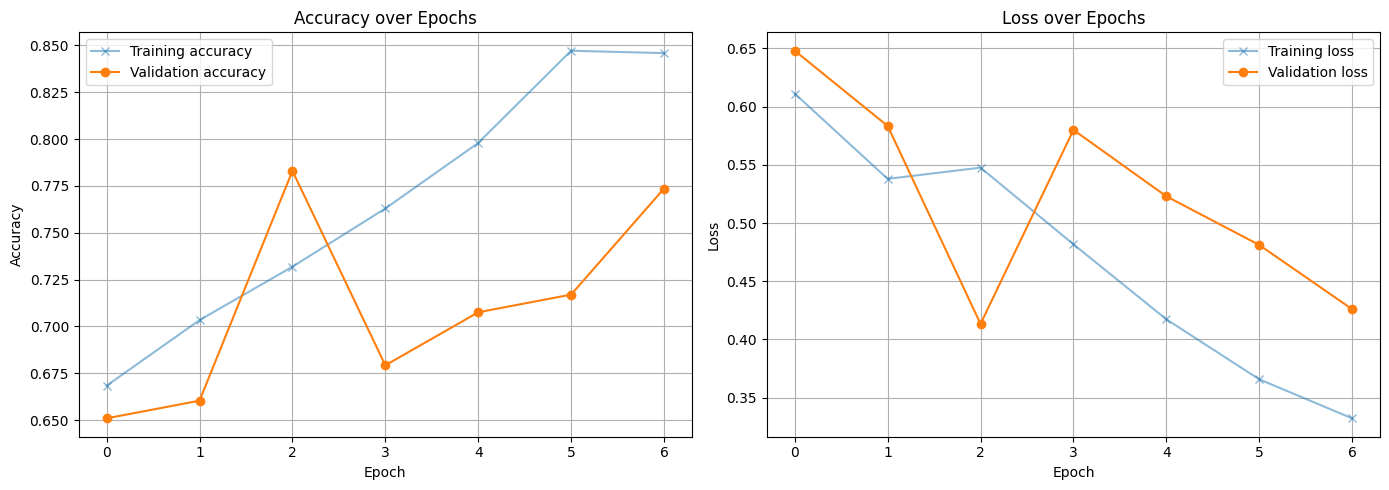

In [ ]:
plot_training_history(history_finetune)

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step
Evaluation Metrics:
Accuracy: 0.8396
F1_score: 0.8322
Precision: 0.8298
Recall: 0.8396

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.52      0.59        23
           1       0.88      0.93      0.90        83

    accuracy                           0.84       106
   macro avg       0.77      0.72      0.74       106
weighted avg       0.83      0.84      0.83       106



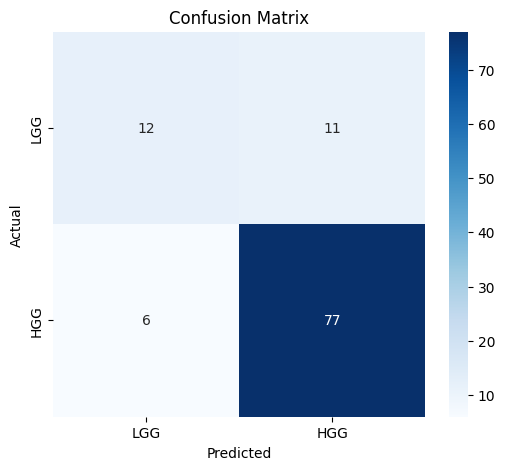

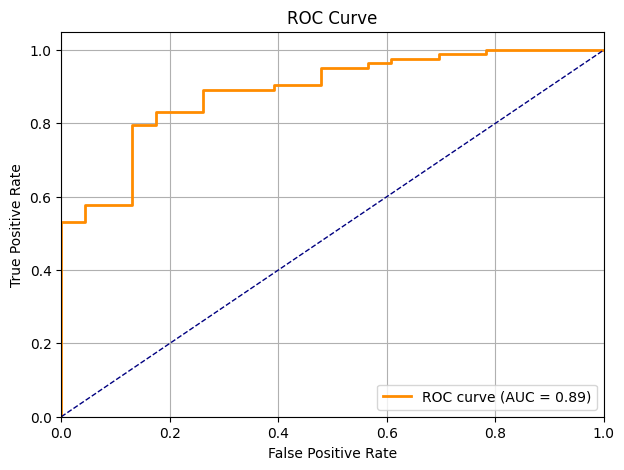

{'accuracy': 0.839622641509434,
 'f1_score': 0.8321882325079457,
 'precision': 0.8297955974842767,
 'recall': 0.839622641509434}

In [ ]:
y_pred_finetune, y_prob_finetune = test_model(model_finetune, test_ds)
evaluate_model(
    y_true=np.concatenate([y for _,y in test_ds], axis=0),
    y_pred=y_pred_finetune,
    y_prob=y_prob_finetune,
    class_names=["LGG","HGG"]
)

In [ ]:
model_baseline =  tf.keras.models.load_model(
    "/content/drive/MyDrive/ProjectData/BraTS2020/best_vgg16_model_baseline.keras"
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 83s 19s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 67s 16s/step


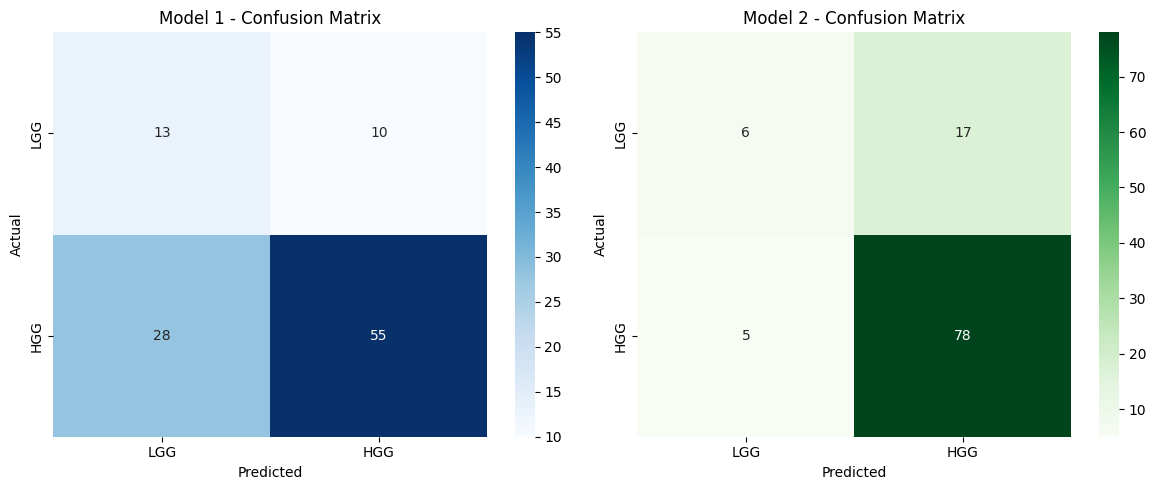

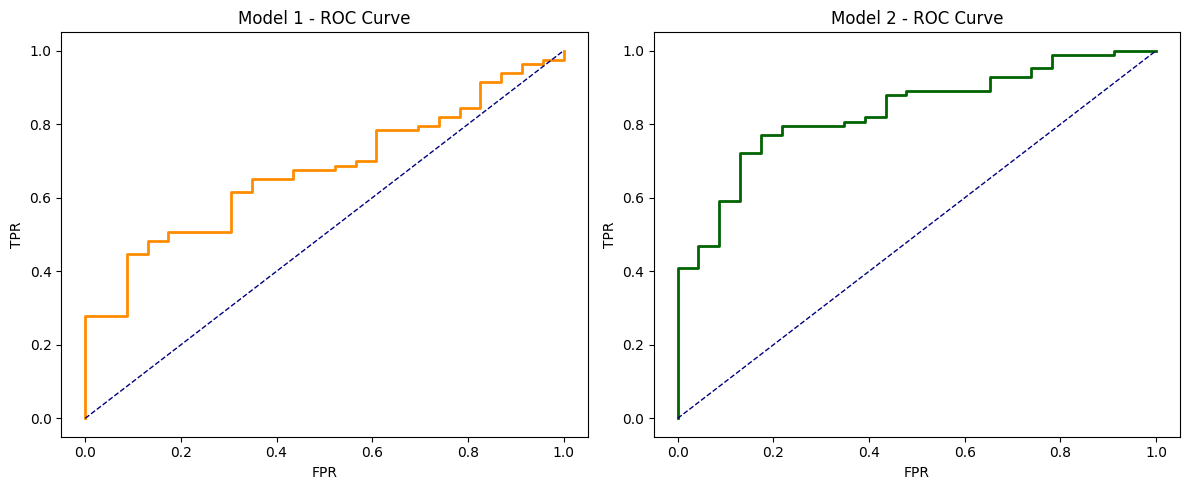

=== F1, Precision, Recall, Accuracy Comparison ===


,accuracy,f1_score,precision,recall
Model 1,0.641509,0.670122,0.731353,0.641509
Model 2,0.792453,0.762823,0.761253,0.792453


In [ ]:
compare_models_side_by_side(
    model1=model_baseline,
    model2=model_finetune,
    test_ds=test_ds,
    class_names=["LGG","HGG"]
)

# Implementing Domain Shift Adaption In Grade Classification

In [ ]:
# ===================================================
#  Define Data Augmentation
# ===================================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


## Domain Shift on Base Model VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)



# ---------------------------
# Build VGG16 Model
# ---------------------------
base_model = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False  # freeze for first stage

inputs = layers.Input(shape=IMG_SIZE + (3,))

# apply augmentation ONLY in training
x = data_augmentation(inputs, training=True)

# preprocess for VGG16 (important!)
x = layers.Lambda(tf.keras.applications.vgg16.preprocess_input)(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

base_model_grade_aug = models.Model(inputs, outputs)

base_model_grade_aug.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

base_model_grade_aug.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Callbacks
callbacks_baseline = make_callbacks("vgg16_baseline_grade_aug")

In [ ]:

# Train baseline
history_baseline_grade_aug = base_model_grade_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_baseline
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 556s 22s/step - accuracy: 0.5168 - loss: 1.0043 - val_accuracy: 0.7830 - val_loss: 0.5611
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 558s 22s/step - accuracy: 0.4563 - loss: 0.9315 - val_accuracy: 0.7830 - val_loss: 0.6625
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 567s 22s/step - accuracy: 0.4933 - loss: 0.8583 - val_accuracy: 0.2453 - val_loss: 0.6955
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 564s 23s/step - accuracy: 0.4685 - loss: 0.8582 - val_accuracy: 0.7830 - val_loss: 0.6747
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 548s 22s/step - accuracy: 0.5026 - loss: 0.8584 - val_accuracy: 0.7830 - val_loss: 0.6689
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 563s 23s/step - accuracy: 0.4910 - loss: 0.8463 - val_accuracy: 0.7830 - val_loss: 0.6878
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 565s 23s/step - accuracy: 0.4851 - loss: 0.8425 - val_accuracy: 0.2170 - val_loss: 0.7004


In [ ]:
# Train baseline
history_baseline_grade_aug = base_model_grade_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_baseline
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 686s 22s/step - accuracy: 0.4706 - loss: 0.9627 - val_accuracy: 0.7830 - val_loss: 0.5875
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 501s 20s/step - accuracy: 0.5204 - loss: 0.7769 - val_accuracy: 0.7830 - val_loss: 0.6818
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 461s 18s/step - accuracy: 0.4764 - loss: 0.8166 - val_accuracy: 0.2170 - val_loss: 0.7049
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 469s 19s/step - accuracy: 0.5299 - loss: 0.7667 - val_accuracy: 0.2170 - val_loss: 0.7176
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 526s 20s/step - accuracy: 0.4951 - loss: 0.8134 - val_accuracy: 0.2170 - val_loss: 0.7016
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 464s 19s/step - accuracy: 0.5262 - loss: 0.8185 - val_accuracy: 0.7830 - val_loss: 0.6904
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 501s 18s/step - accuracy: 0.4879 - loss: 0.7714 - val_accuracy: 0.7830 - val_loss: 0.6902


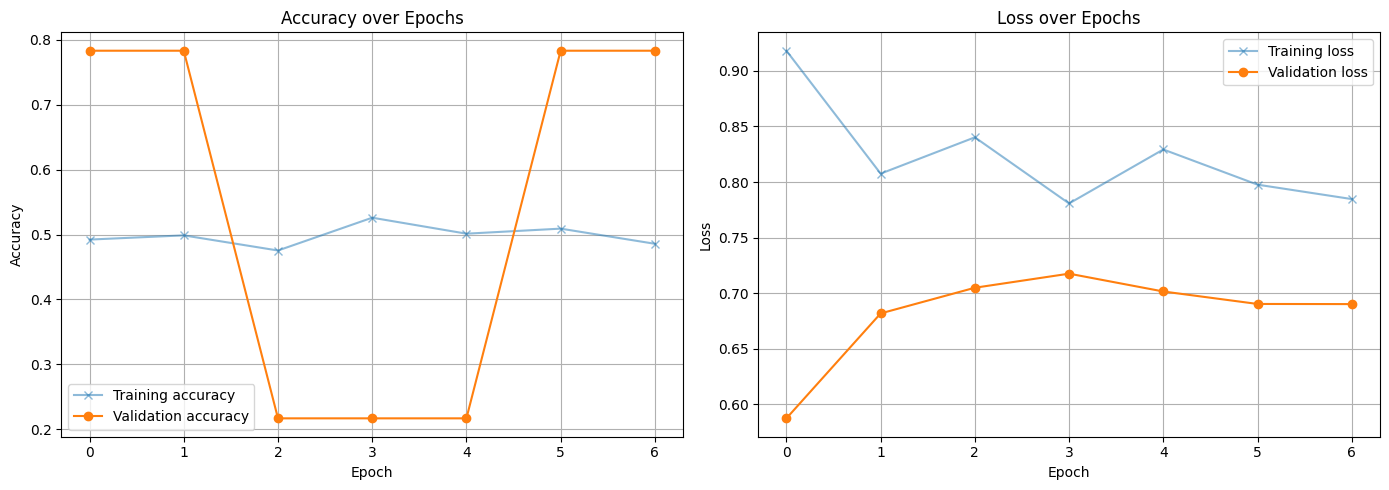

In [ ]:
plot_training_history(history_baseline_grade_aug)

4/4 ━━━━━━━━━━━━━━━━━━━━ 62s 13s/step
Evaluation Metrics:
Accuracy: 0.7830
F1_score: 0.6877
Precision: 0.6131
Recall: 0.7830

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.78      1.00      0.88        83

    accuracy                           0.78       106
   macro avg       0.39      0.50      0.44       106
weighted avg       0.61      0.78      0.69       106



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

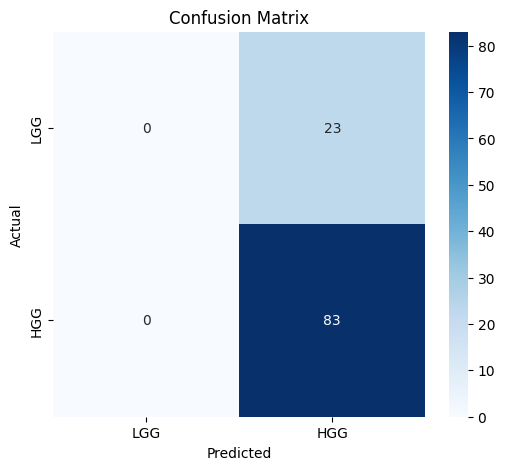

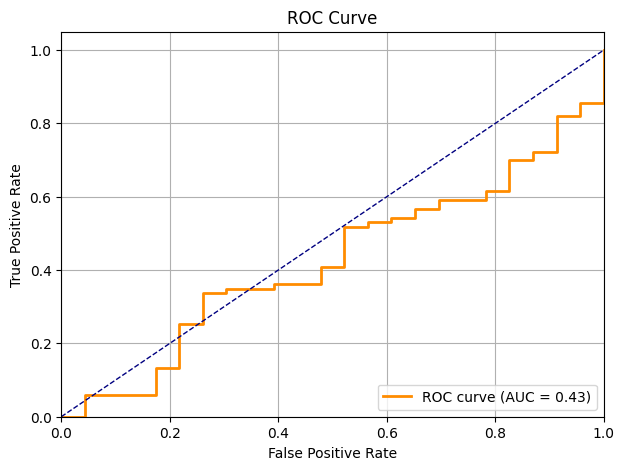

{'accuracy': 0.7830188679245284,
 'f1_score': 0.6877308575421783,
 'precision': 0.61311854752581,
 'recall': 0.7830188679245284}

In [ ]:
y_pred_base, y_prob_base = test_model(base_model_grade_aug, test_ds)
evaluate_model(
    y_true=np.concatenate([y for _,y in test_ds], axis=0),
    y_pred=y_pred_base,
    y_prob=y_prob_base,
    class_names=["LGG","HGG"]
)

## Domain Shift on Fine-Tune VGG16

In [ ]:
baseline_tuned_aug = tf.keras.models.load_model(
    "/content/drive/MyDrive/ProjectData/BraTS2020/best_vgg16_finetune.keras"
)


In [ ]:
model_finetune_aug.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │    14,846,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,268,293 (111.65 MB)

 Trainable params: 7,211,009 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,422,020 (55.02 MB)

In [ ]:
# Unfreeze only last 4 layers in the base model
base_model = baseline_tuned_aug.layers[0]  # extract VGG16 backbone

for layer in base_model.layers[:-4]:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

print("Trainable layers:", sum([l.trainable for l in base_model.layers]))


Trainable layers: 4


In [ ]:
# Re-wrap with augmentation
model_finetune_aug = tf.keras.models.Sequential([
    data_augmentation,
    baseline_tuned_aug
])

In [ ]:
model_finetune_aug.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/ProjectData/BraTS2020/best_vgg16_finetune_aug.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

In [ ]:
history_finetune_aug = model_finetune_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[earlystop, reduce_lr, checkpoint]
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - accuracy: 0.7019 - loss: 0.5411 - val_accuracy: 0.7736 - val_loss: 0.4459 - learning_rate: 1.0000e-05
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - accuracy: 0.7318 - loss: 0.4869 - val_accuracy: 0.6981 - val_loss: 0.5474 - learning_rate: 1.0000e-05
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.7725 - loss: 0.4791 - val_accuracy: 0.7358 - val_loss: 0.4842 - learning_rate: 1.0000e-05
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.7574 - loss: 0.4863 - val_accuracy: 0.7453 - val_loss: 0.4775 - learning_rate: 5.0000e-06
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.7795 - loss: 0.4549 - val_accuracy: 0.7453 - val_loss: 0.4818 - learning_rate: 5.0000e-06


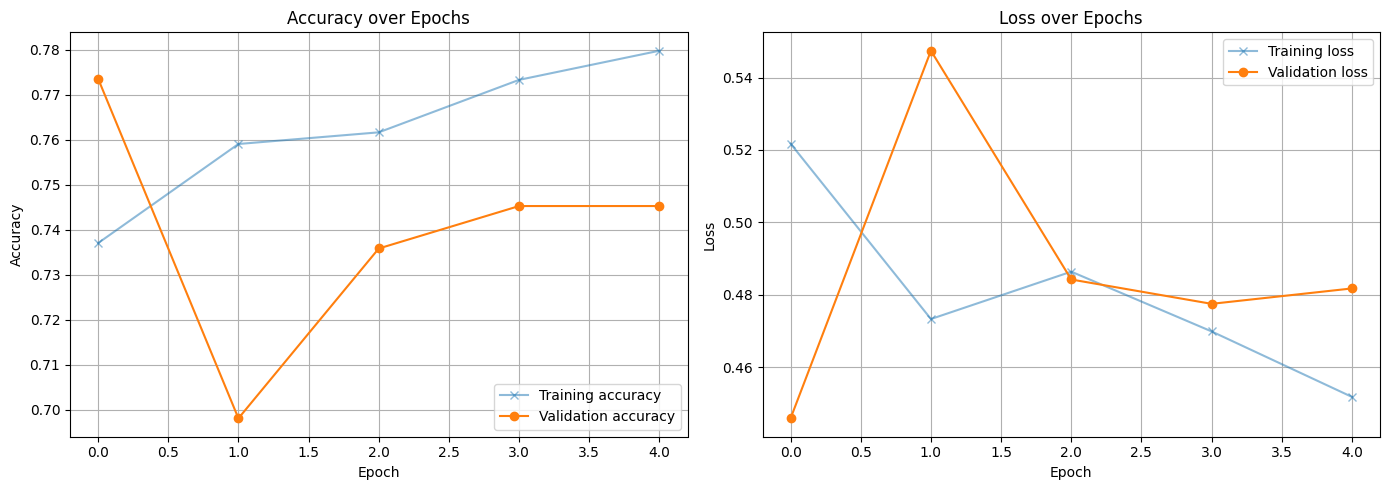

In [ ]:
plot_training_history(history_finetune_aug)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step
Evaluation Metrics:
Accuracy: 0.7830
F1_score: 0.7977
Precision: 0.8356
Recall: 0.7830

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.78      0.61        23
           1       0.93      0.78      0.85        83

    accuracy                           0.78       106
   macro avg       0.71      0.78      0.73       106
weighted avg       0.84      0.78      0.80       106



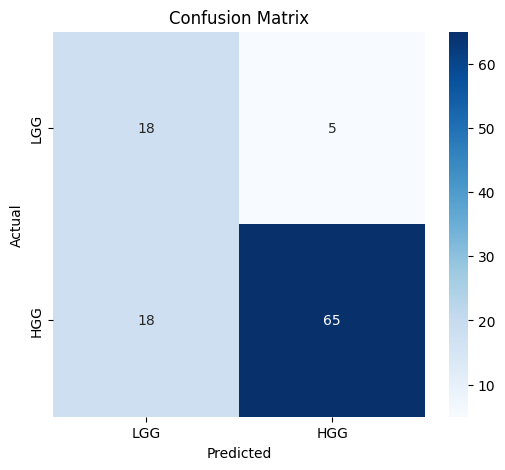

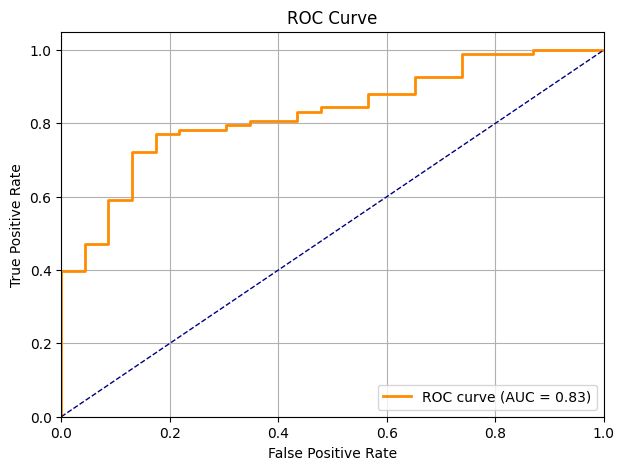

{'accuracy': 0.7830188679245284,
 'f1_score': 0.7977054162460209,
 'precision': 0.8355795148247979,
 'recall': 0.7830188679245284}

In [ ]:
y_pred_base, y_prob_base = test_model(model_finetune_aug, test_ds)
evaluate_model(
    y_true=np.concatenate([y for _,y in test_ds], axis=0),
    y_pred=y_pred_base,
    y_prob=y_prob_base,
    class_names=["LGG","HGG"]
)

In [ ]:
model_tuned_aug = tf.keras.models.load_model("/content/drive/MyDrive/ProjectData/BraTS2020/best_vgg16_finetune.keras")


In [ ]:
from tensorflow.keras import models, layers

# Define moderate augmentation to tune the model more

moderate_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.GaussianNoise(0.02)
])

model_tuned_domain_shift = models.Sequential([
    moderate_augmentation,
    model_tuned_aug
])


In [ ]:
optimizer = tf.keras.optimizers.Adam(1e-6)

model_tuned_domain_shift.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_tuned_domain_shift = model_tuned_domain_shift.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[earlystop, reduce_lr, checkpoint],
    # class_weight=class_weight
)


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.4925 - loss: 1.3123 - val_accuracy: 0.8113 - val_loss: 0.4371 - learning_rate: 1.0000e-06
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.5539 - loss: 1.1571 - val_accuracy: 0.7830 - val_loss: 0.4636 - learning_rate: 1.0000e-06
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.5083 - loss: 1.1786 - val_accuracy: 0.7642 - val_loss: 0.4933 - learning_rate: 1.0000e-06
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.4816 - loss: 1.1516 - val_accuracy: 0.7453 - val_loss: 0.5106 - learning_rate: 5.0000e-07
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.5462 - loss: 1.0858 - val_accuracy: 0.7358 - val_loss: 0.5257 - learning_rate: 5.0000e-07
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.5303 - loss: 1.1103 - val_accuracy: 0.7170 - val_loss: 0.5339 - learning_rate: 2.5000e-07
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - accuracy:

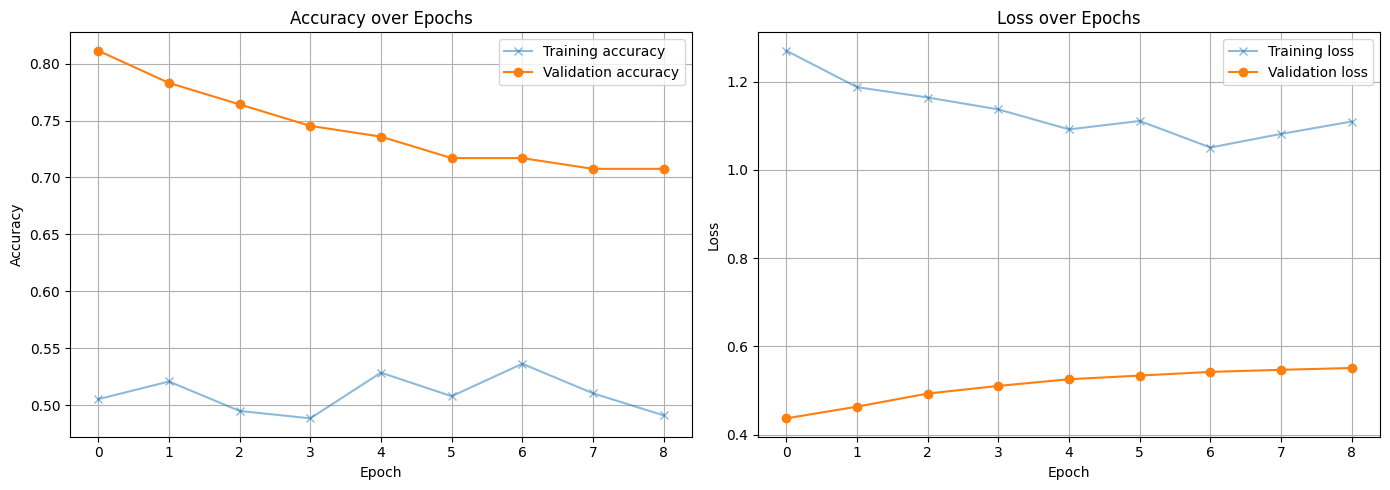

In [ ]:
plot_training_history(history_tuned_domain_shift)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step
Evaluation Metrics:
Accuracy: 0.8019
F1_score: 0.8003
Precision: 0.7988
Recall: 0.8019

Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.52      0.53        23
           1       0.87      0.88      0.87        83

    accuracy                           0.80       106
   macro avg       0.71      0.70      0.70       106
weighted avg       0.80      0.80      0.80       106



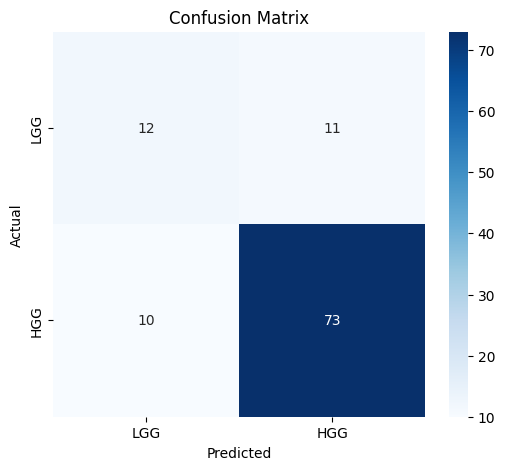

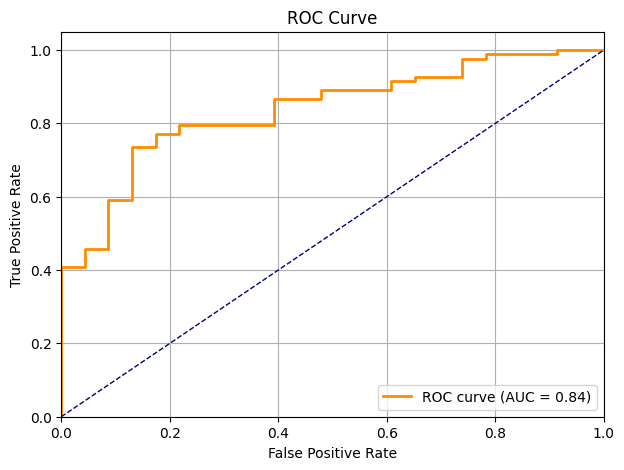

{'accuracy': 0.8018867924528302,
 'f1_score': 0.8002786879072045,
 'precision': 0.7988340276076125,
 'recall': 0.8018867924528302}

In [ ]:
y_pred_base, y_prob_base = test_model(model_tuned_domain_shift, test_ds)
evaluate_model(
    y_true=np.concatenate([y for _,y in test_ds], axis=0),
    y_pred=y_pred_base,
    y_prob=y_prob_base,
    class_names=["LGG","HGG"]
)

In [ ]:
# Define the stronger augmentation to simulate domain shift and predict on this
data_augmentation_domain_shift = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),       # bigger rotation
    layers.RandomZoom(0.1),           # bigger zoom
    layers.RandomContrast(0.4),       # stronger contrast
    layers.RandomBrightness(0.3),     # simulate scanner brightness variation
    layers.GaussianNoise(0.03),       # simulate noise
])


In [ ]:
# Predict on test data with strong data augmentation
test_ds_shift = test_ds.map(lambda x, y: (data_augmentation_domain_shift(x, training=True), y))


In [ ]:
y_pred_shift = (model_finetune_aug.predict(test_ds_shift) > 0.5).astype(int)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix
y_true = np.concatenate([y for x, y in test_ds_shift], axis=0)
print(classification_report(y_true, y_pred_shift))
print(confusion_matrix(y_true, y_pred_shift))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step
              precision    recall  f1-score   support

           0       0.80      0.17      0.29        23
           1       0.81      0.99      0.89        83

    accuracy                           0.81       106
   macro avg       0.81      0.58      0.59       106
weighted avg       0.81      0.81      0.76       106

[[ 4 19]
 [ 1 82]]


In [ ]:
import numpy as np

# Get probabilities (not rounded)
y_prob = model_finetune_aug.predict(test_ds)
y_prob = y_prob.flatten()  # shape (num_samples,)

y_true = np.concatenate([y for x, y in test_ds])
y_true = y_true.flatten()

from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

thresholds = np.arange(0.1, 0.9, 0.01)
precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    precisions.append(precision_score(y_true, y_pred))
    recalls.append(recall_score(y_true, y_pred))
    f1s.append(f1_score(y_true, y_pred))

# Convert to arrays
precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


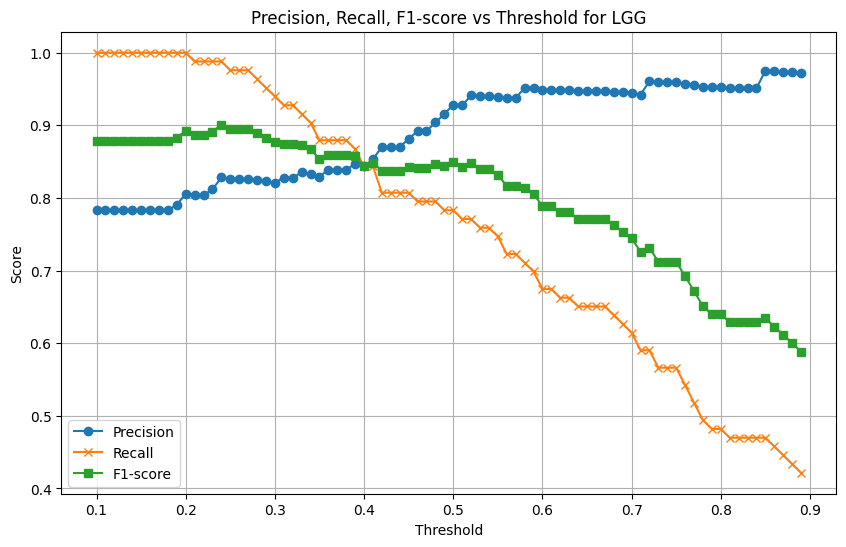

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions, label='Precision', marker='o')
plt.plot(thresholds, recalls, label='Recall', marker='x')
plt.plot(thresholds, f1s, label='F1-score', marker='s')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1-score vs Threshold for LGG')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
y_pred_shift = (model_finetune_aug.predict(test_ds_shift) > 0.4).astype(int)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix
y_true = np.concatenate([y for x, y in test_ds_shift], axis=0)
print(classification_report(y_true, y_pred_shift))
print(confusion_matrix(y_true, y_pred_shift))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 498ms/step
              precision    recall  f1-score   support

           0       1.00      0.09      0.16        23
           1       0.80      1.00      0.89        83

    accuracy                           0.80       106
   macro avg       0.90      0.54      0.52       106
weighted avg       0.84      0.80      0.73       106

[[ 2 21]
 [ 0 83]]


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 374ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 377ms/step


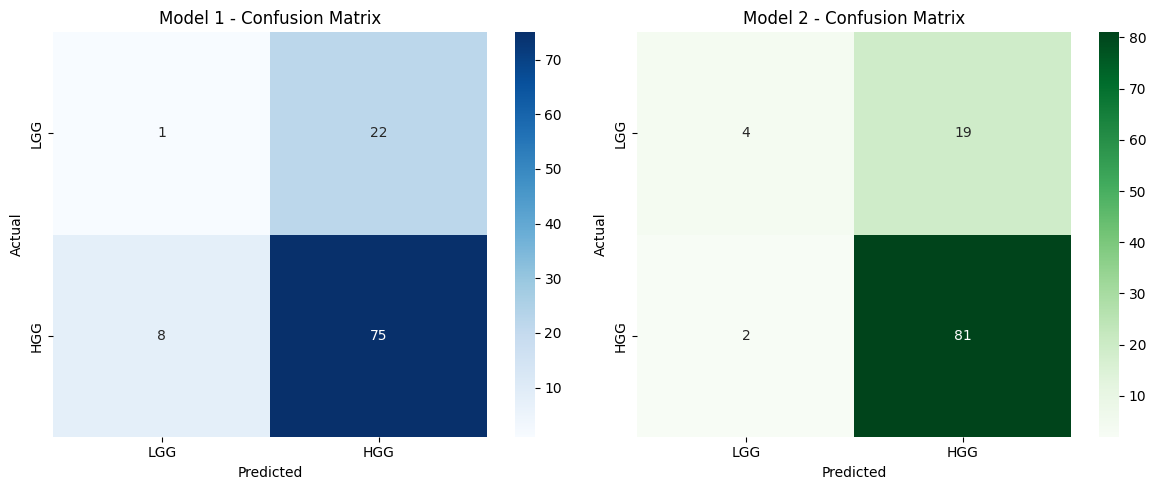

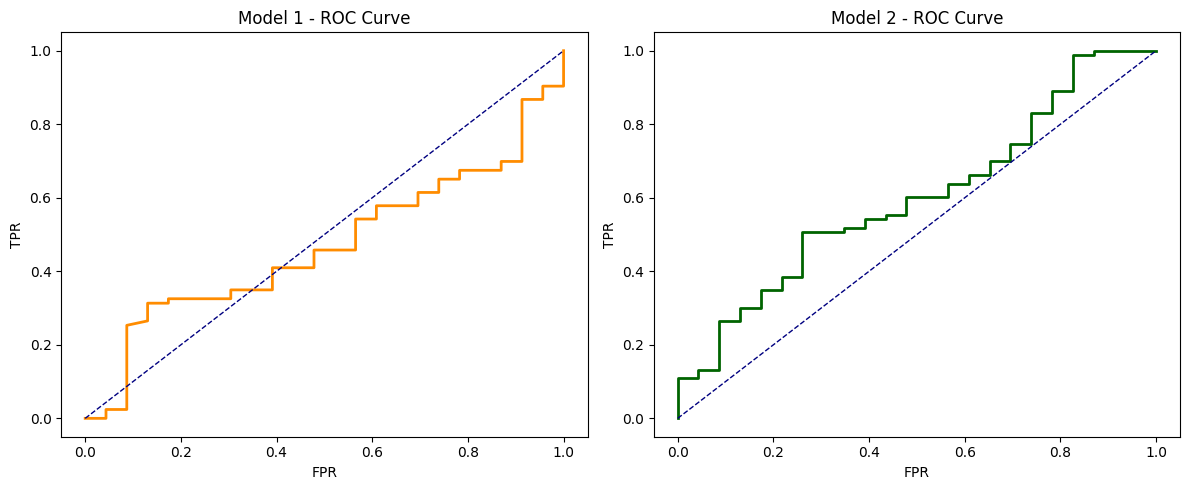

=== F1, Precision, Recall, Accuracy Comparison ===


,accuracy,f1_score,precision,recall
Model 1,0.716981,0.666077,0.629536,0.716981
Model 2,0.801887,0.753021,0.778899,0.801887


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
vgg16_baseline_grade_aug_best = tf.keras.models.load_model(
    "/content/drive/MyDrive/ProjectData/combined_splits/vgg16_baseline_grade_aug_best.keras",
     custom_objects={'preprocess_input': preprocess_input}
)
# baseline_tuned_aug = tf.keras.models.load_model(
#     "/content/drive/MyDrive/ProjectData/BraTS2020/best_vgg16_finetune.keras"
# )
class_names = ['LGG', 'HGG']
compare_models_side_by_side(vgg16_baseline_grade_aug_best, model_finetune_aug, test_ds_shift,class_names=class_names)